# **ML Assignment: Employee Attrition Prediction from HR Analytics**

*A binary classification study of employee attrition using IBM's HR Analytics case-study dataset, incorporating an explicit dataset-provenance and signal-validation procedure prior to model development.*

## Problem Definition and Domain Understanding

**Objective.** Employee attrition entails direct replacement costs, typically equivalent to several months of salary in recruiting, onboarding, and lost productivity. Early identification of high-risk employees enables targeted intervention (retention discussions, workload adjustment, compensation review) prior to resignation.

**Task formulation.** The problem is formulated as binary classification: predicting `Attrition` (`Yes`/`No`) from demographic, compensation, and job-satisfaction attributes.

**Data source.** The [`saadharoon27/hr-analytics-dataset`](https://www.kaggle.com/datasets/saadharoon27/hr-analytics-dataset) repository on Kaggle, a redistribution of IBM's *HR Analytics Employee Attrition & Performance* dataset (1,470 employee records in the original release; 1,480 rows in this copy, including a small number of duplicated and derived columns). IBM's documentation identifies this dataset as fictional, constructed to demonstrate Watson Analytics rather than sourced from payroll records. Section 2 evaluates whether the dataset nonetheless exhibits statistically meaningful structure suitable for a modeling exercise, as opposed to data with no genuine relationship between features and target.

**Analysis plan.**
1. Dataset provenance and signal-validation assessment.
2. Exploratory data analysis and feature engineering.
3. Leakage-safe preprocessing and train/test partitioning.
4. Baseline model training and evaluation across five classifiers.
5. Hyperparameter tuning and decision-threshold optimization (F-beta criteria, capacity-constrained ranking).
6. Feature-importance analysis, production pipeline assembly, and concluding assessment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import kagglehub
from kagglehub import KaggleDatasetAdapter

sns.set_theme(style="whitegrid")

ATTRITION_ORDER = ["No", "Yes"]
ATTRITION_PALETTE = {"No": "#4C72B0", "Yes": "#DD8452"}

file_path = "HR_Analytics.csv"
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "saadharoon27/hr-analytics-dataset",
    file_path,
)

print("Dataset shape:", df.shape)
print()
print("Column dtypes:")
print(df.dtypes)
df.head()

C:\Users\sveta\Documents\ML-Mood-Predictor-from-Fitness-Behavior\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset shape: (1480, 38)

Column dtypes:
EmpID                           str
Age                           int64
AgeGroup                        str
Attrition                       str
BusinessTravel                  str
DailyRate                     int64
Department                      str
DistanceFromHome              int64
Education                     int64
EducationField                  str
EmployeeCount                 int64
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                          str
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                         str
JobSatisfaction               int64
MaritalStatus                   str
MonthlyIncome                 int64
SalarySlab                      str
MonthlyRate                   int64
NumCompaniesWorked            int64
Over18                          str
OverTime                        str
PercentSalaryHike     

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


## Dataset Provenance and Signal Validation

Prior to model development, the dataset was evaluated for evidence of genuine underlying structure, as distinct from placeholder data exhibiting no systematic relationship between features and target — a pattern observed in several candidate datasets considered during dataset selection and excluded on this basis. Four criteria were examined:

1. **Row-level integrity**: duplicate rows and duplicate identifiers.
2. **Degenerate columns**: constant-valued columns carrying no information.
3. **Missingness pattern**: irregular and plausible, versus uniform or absent (suggestive of synthetic generation).
4. **Statistical association with the target**: whether feature distributions differ significantly between `Attrition = Yes` and `Attrition = No`.

In [2]:
print("=== Row-level integrity ===")
print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Unique EmployeeNumber: {df['EmployeeNumber'].nunique()} out of {len(df)} rows")
print(f"Unique EmpID: {df['EmpID'].nunique()} out of {len(df)} rows")
print()

print("=== Degenerate (zero-variance) columns ===")
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"  {col}: constant value = {df[col].unique()[0]!r}")
print()

print("=== Missing values ===")
missing = df.isna().sum()
print(missing[missing > 0])

=== Row-level integrity ===
Exact duplicate rows: 7
Unique EmployeeNumber: 1470 out of 1480 rows
Unique EmpID: 1470 out of 1480 rows

=== Degenerate (zero-variance) columns ===
  EmployeeCount: constant value = np.int64(1)
  Over18: constant value = 'Y'
  StandardHours: constant value = np.int64(80)

=== Missing values ===
YearsWithCurrManager    57
dtype: int64


In [3]:
print("=== Statistical association between features and Attrition ===\n")

numeric_probe_cols = ["MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "Age"]
for col in numeric_probe_cols:
    yes_vals = df.loc[df["Attrition"] == "Yes", col]
    no_vals = df.loc[df["Attrition"] == "No", col]
    t_stat, p_value = stats.ttest_ind(yes_vals, no_vals, equal_var=False)
    print(f"{col:20s}  mean(Yes)={yes_vals.mean():9.1f}  mean(No)={no_vals.mean():9.1f}  "
          f"Welch t={t_stat:6.2f}  p-value={p_value:.2e}")

print()

categorical_probe_cols = ["OverTime", "JobRole", "MaritalStatus"]
for col in categorical_probe_cols:
    contingency = pd.crosstab(df[col], df["Attrition"])
    chi2, p_value, dof, _ = stats.chi2_contingency(contingency)
    print(f"{col:15s}  chi2={chi2:8.2f}  dof={dof}  p-value={p_value:.2e}")

=== Statistical association between features and Attrition ===

MonthlyIncome         mean(Yes)=   4812.6  mean(No)=   6829.3  Welch t= -7.38  p-value=8.93e-13
TotalWorkingYears     mean(Yes)=      8.3  mean(No)=     11.9  Welch t= -6.91  p-value=2.36e-11
YearsAtCompany        mean(Yes)=      5.1  mean(No)=      7.4  Welch t= -5.33  p-value=1.79e-07
Age                   mean(Yes)=     33.7  mean(No)=     37.5  Welch t= -5.69  p-value=2.92e-08

OverTime         chi2=   89.77  dof=1  p-value=2.67e-21
JobRole          chi2=   85.53  dof=8  p-value=3.75e-15
MaritalStatus    chi2=   45.11  dof=2  p-value=1.60e-10


**Findings.**
- `EmployeeCount` (=1), `StandardHours` (=80), and `Over18` (='Y') are constant across all records and were excluded as uninformative.
- `EmployeeNumber` and `EmpID` are unique identifiers (1,470 distinct values across 1,480 rows, indicating a small number of duplicated records) and were removed prior to modeling to prevent the model from associating predictions with specific individuals.
- A small number of exact duplicate rows were identified and removed during preprocessing.
- Missing values are restricted to `YearsWithCurrManager` (57 observations, approximately 3.9% of records), consistent with an irregular, plausible missingness mechanism rather than an artificially uniform or absent one.
- All tested features exhibit a statistically significant association with `Attrition` (p < 0.001 in each case): employees who leave report lower income, shorter tenure, and a higher incidence of overtime. This pattern is inconsistent with randomly assigned labels and supports proceeding with model development.

**Caveat.** IBM's documentation identifies this dataset as fictional, constructed for Watson Analytics demonstration purposes rather than derived from payroll records. It is treated here as a synthetic case study with statistically grounded, domain-plausible relationships, suitable for demonstrating a complete modeling pipeline; it should not be interpreted as representing real employee outcomes. This distinction is noted for inclusion in any derived report.

## Data Cleaning

The following records and columns were removed prior to analysis, based on the findings above:
- Identifier columns `EmpID` and `EmployeeNumber`.
- Constant columns `EmployeeCount`, `StandardHours`, and `Over18`.
- Exact duplicate rows.

In [4]:
print(f"Shape before cleaning: {df.shape}")

id_cols = ["EmpID", "EmployeeNumber"]
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
cols_to_drop = [col for col in id_cols + constant_cols if col in df.columns]

df_clean = df.drop(columns=cols_to_drop).drop_duplicates().reset_index(drop=True)

# Data-entry inconsistency found while investigating BusinessTravel: "TravelRarely"
# (7 rows, no underscore) is the same category as "Travel_Rarely" (1038 rows), just
# typed differently. Consolidate before it fragments the one-hot encoding.
df_clean["BusinessTravel"] = df_clean["BusinessTravel"].replace({"TravelRarely": "Travel_Rarely"})

print(f"Dropped columns: {cols_to_drop}")
print(f"Shape after cleaning: {df_clean.shape}")
print(f"Remaining duplicate rows: {df_clean.duplicated().sum()}")
missing_after = df_clean.isna().sum()
print(f"Remaining missing values:\n{missing_after[missing_after > 0]}")

Shape before cleaning: (1480, 38)
Dropped columns: ['EmpID', 'EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
Shape after cleaning: (1473, 33)
Remaining duplicate rows: 0
Remaining missing values:
YearsWithCurrManager    57
dtype: int64


## Exploratory Data Analysis

Following data cleaning, the target distribution and its relationship with candidate predictor variables were examined.

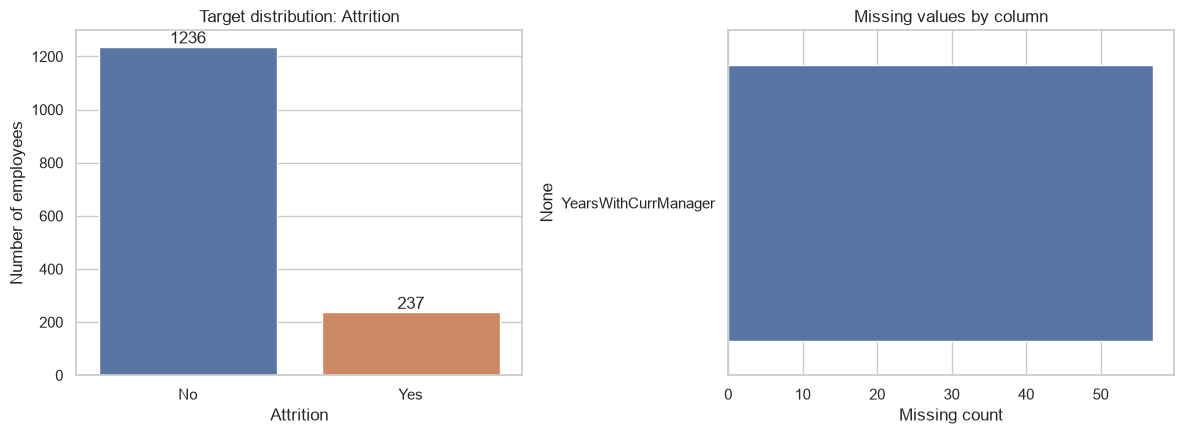

Attrition
No     83.91
Yes    16.09
Name: proportion, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(
    data=df_clean, x="Attrition", order=ATTRITION_ORDER,
    hue="Attrition", palette=ATTRITION_PALETTE, legend=False, ax=axes[0]
)
axes[0].set_title("Target distribution: Attrition")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Number of employees")
for container in axes[0].containers:
    axes[0].bar_label(container)

missing_counts = df_clean.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
sns.barplot(x=missing_counts.values, y=missing_counts.index, color="#4C72B0", ax=axes[1])
axes[1].set_title("Missing values by column")
axes[1].set_xlabel("Missing count")

plt.tight_layout()
plt.show()

print(df_clean["Attrition"].value_counts(normalize=True).mul(100).round(2))

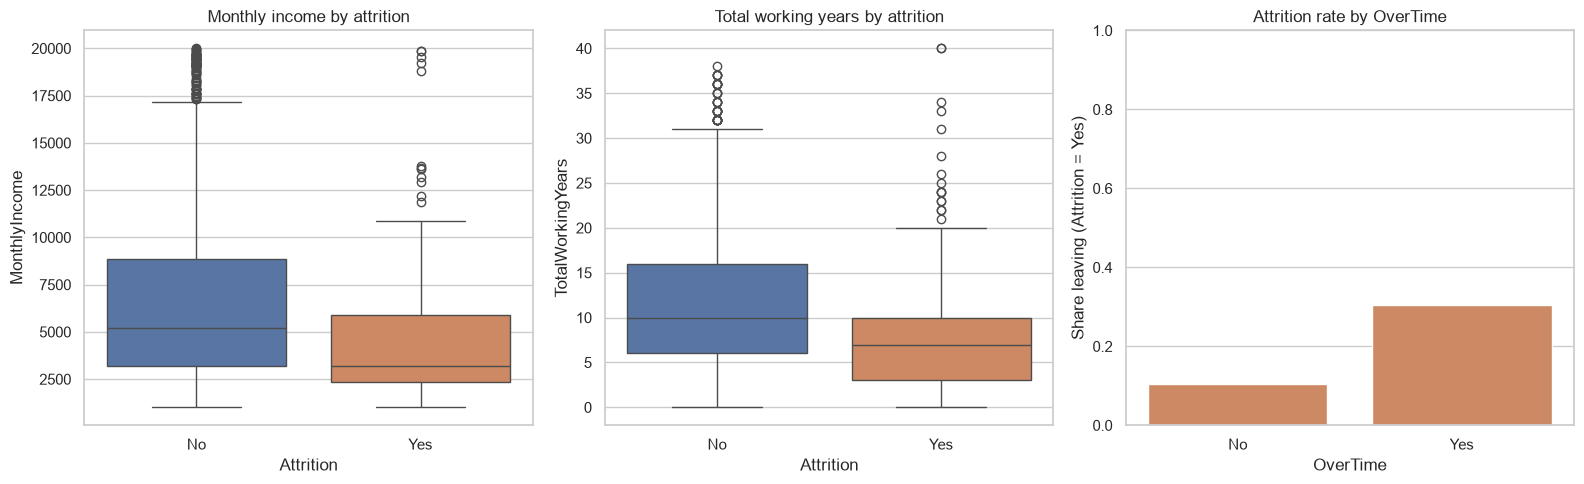

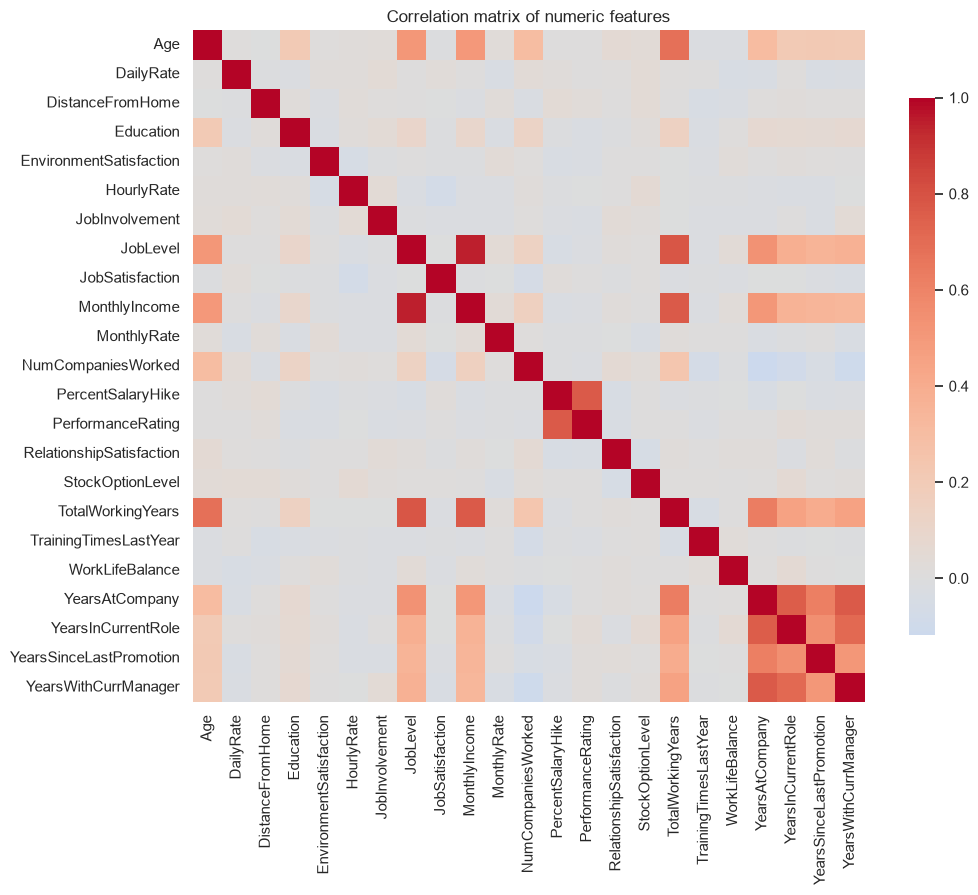

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(
    data=df_clean, x="Attrition", y="MonthlyIncome", order=ATTRITION_ORDER,
    hue="Attrition", palette=ATTRITION_PALETTE, legend=False, ax=axes[0]
)
axes[0].set_title("Monthly income by attrition")

sns.boxplot(
    data=df_clean, x="Attrition", y="TotalWorkingYears", order=ATTRITION_ORDER,
    hue="Attrition", palette=ATTRITION_PALETTE, legend=False, ax=axes[1]
)
axes[1].set_title("Total working years by attrition")

overtime_rate = (
    df_clean.groupby("OverTime")["Attrition"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
)
overtime_rate = overtime_rate[overtime_rate["Attrition"] == "Yes"]
sns.barplot(data=overtime_rate, x="OverTime", y="share", color="#DD8452", ax=axes[2])
axes[2].set_title("Attrition rate by OverTime")
axes[2].set_ylabel("Share leaving (Attrition = Yes)")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(11, 9))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix of numeric features")
plt.tight_layout()
plt.show()

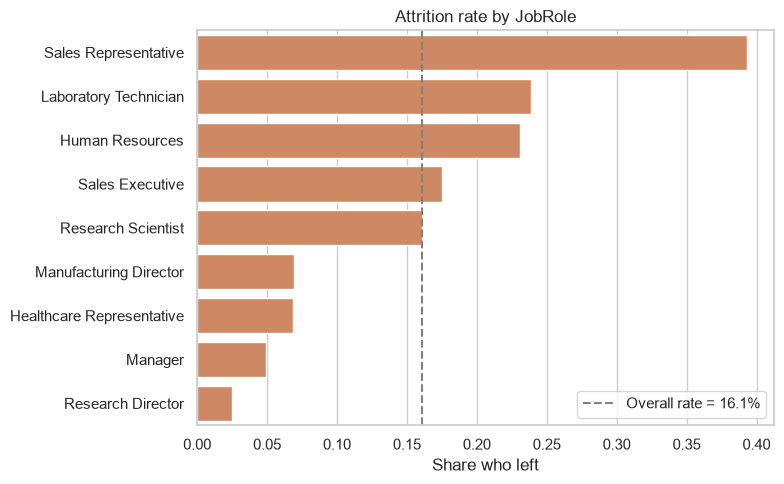

JobRole
Sales Representative         0.393
Laboratory Technician        0.238
Human Resources              0.231
Sales Executive              0.175
Research Scientist           0.161
Manufacturing Director       0.069
Healthcare Representative    0.068
Manager                      0.049
Research Director            0.025
Name: Attrition, dtype: float64


In [7]:
role_attrition = (
    df_clean.groupby("JobRole")["Attrition"]
    .apply(lambda s: (s == "Yes").mean())
    .sort_values(ascending=False)
)
overall_rate = df_clean["Attrition"].eq("Yes").mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=role_attrition.values, y=role_attrition.index, color="#DD8452")
plt.axvline(overall_rate, color="gray", linestyle="--", label=f"Overall rate = {overall_rate:.1%}")
plt.title("Attrition rate by JobRole")
plt.xlabel("Share who left")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

print(role_attrition.round(3))

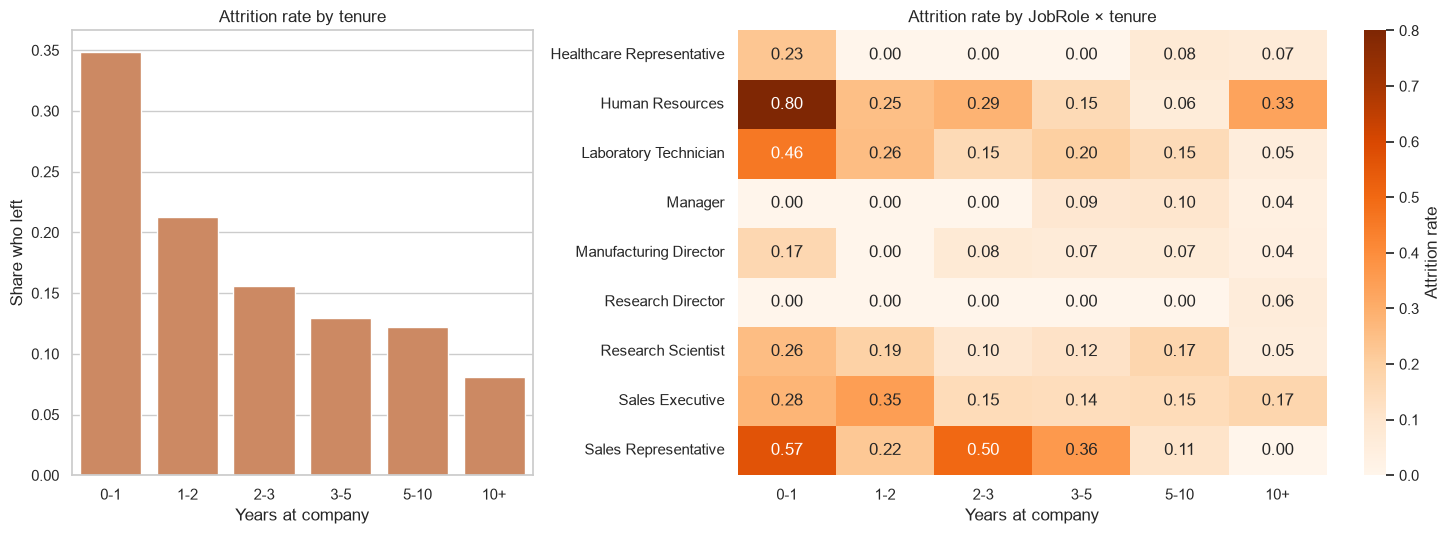

tenure_bucket
0-1     0.349
1-2     0.213
2-3     0.156
3-5     0.130
5-10    0.122
10+     0.081
Name: Attrition, dtype: float64


In [8]:
bins = [-1, 1, 2, 3, 5, 10, 100]
tenure_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10+"]
df_clean["tenure_bucket"] = pd.cut(df_clean["YearsAtCompany"], bins=bins, labels=tenure_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1, 1.6]})

tenure_attrition = (
    df_clean.groupby("tenure_bucket", observed=True)["Attrition"]
    .apply(lambda s: (s == "Yes").mean())
)
sns.barplot(x=tenure_attrition.index, y=tenure_attrition.values, color="#DD8452", ax=axes[0])
axes[0].set_title("Attrition rate by tenure")
axes[0].set_xlabel("Years at company")
axes[0].set_ylabel("Share who left")

role_tenure_pivot = df_clean.pivot_table(
    index="JobRole", columns="tenure_bucket", values="Attrition",
    aggfunc=lambda s: (s == "Yes").mean(), observed=False,
)
sns.heatmap(role_tenure_pivot, annot=True, fmt=".2f", cmap="Oranges",
            cbar_kws={"label": "Attrition rate"}, ax=axes[1])
axes[1].set_title("Attrition rate by JobRole \u00d7 tenure")
axes[1].set_xlabel("Years at company")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

print(tenure_attrition.round(3))

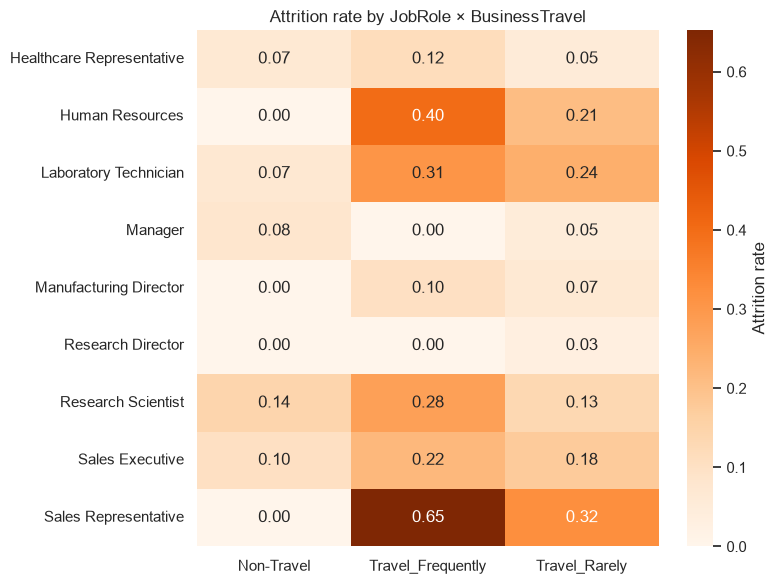

Overall attrition rate by BusinessTravel:
BusinessTravel
Non-Travel           0.080
Travel_Frequently    0.248
Travel_Rarely        0.149
Name: Attrition, dtype: float64

Sample size per cell (roles with <15 in a cell should be read cautiously):
BusinessTravel             Non-Travel  Travel_Frequently  Travel_Rarely
JobRole                                                                
Healthcare Representative          15                 26             91
Human Resources                     4                 10             38
Laboratory Technician              28                 52            180
Manager                            12                 13             77
Manufacturing Director             13                 29            103
Research Director                   6                 12             62
Research Scientist                 28                 54            210
Sales Executive                    39                 59            228
Sales Representative              

In [9]:
travel_role_pivot = df_clean.pivot_table(
    index="JobRole", columns="BusinessTravel", values="Attrition",
    aggfunc=lambda s: (s == "Yes").mean(), observed=False,
)
travel_role_counts = df_clean.pivot_table(
    index="JobRole", columns="BusinessTravel", values="Attrition", aggfunc="count", observed=False,
)

plt.figure(figsize=(8, 6))
sns.heatmap(travel_role_pivot, annot=True, fmt=".2f", cmap="Oranges",
            cbar_kws={"label": "Attrition rate"})
plt.title("Attrition rate by JobRole \u00d7 BusinessTravel")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

print("Overall attrition rate by BusinessTravel:")
print(df_clean.groupby("BusinessTravel")["Attrition"].apply(lambda s: (s == "Yes").mean()).round(3))
print()
print("Sample size per cell (roles with <15 in a cell should be read cautiously):")
print(travel_role_counts.to_string())

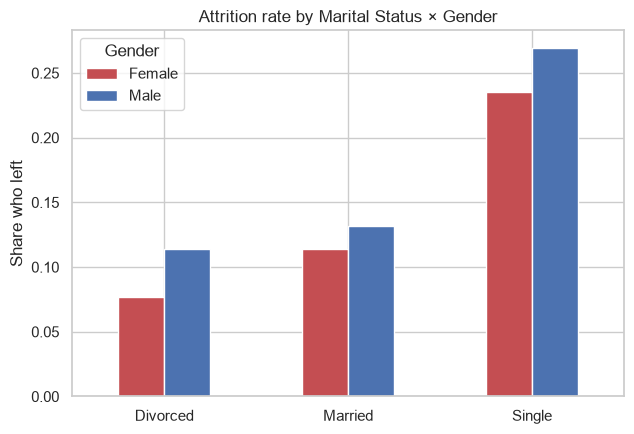

Gender         Female   Male
MaritalStatus               
Divorced        0.077  0.114
Married         0.114  0.132
Single          0.235  0.269

Male: rate(Single)=0.269  rate(not Single)=0.126  chi2 p-value=2.56e-07  (n=884)
Female: rate(Single)=0.235  rate(not Single)=0.103  chi2 p-value=3.20e-05  (n=589)


In [10]:
gender_marital_pivot = df_clean.pivot_table(
    index="MaritalStatus", columns="Gender", values="Attrition",
    aggfunc=lambda s: (s == "Yes").mean(), observed=False,
)

plt.figure(figsize=(6.5, 4.5))
gender_marital_pivot.plot(kind="bar", color=["#C44E52", "#4C72B0"], ax=plt.gca())
plt.title("Attrition rate by Marital Status \u00d7 Gender")
plt.ylabel("Share who left")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

print(gender_marital_pivot.round(3))
print()

# Is the "Single" effect actually different by gender, or just present in both?
for gender in ["Male", "Female"]:
    sub = df_clean[df_clean["Gender"] == gender]
    rate_single = (sub.loc[sub["MaritalStatus"] == "Single", "Attrition"] == "Yes").mean()
    rate_not_single = (sub.loc[sub["MaritalStatus"] != "Single", "Attrition"] == "Yes").mean()
    contingency = pd.crosstab(sub["MaritalStatus"] == "Single", sub["Attrition"])
    chi2, p_value, _, _ = stats.chi2_contingency(contingency)
    print(f"{gender}: rate(Single)={rate_single:.3f}  rate(not Single)={rate_not_single:.3f}  "
          f"chi2 p-value={p_value:.2e}  (n={len(sub)})")

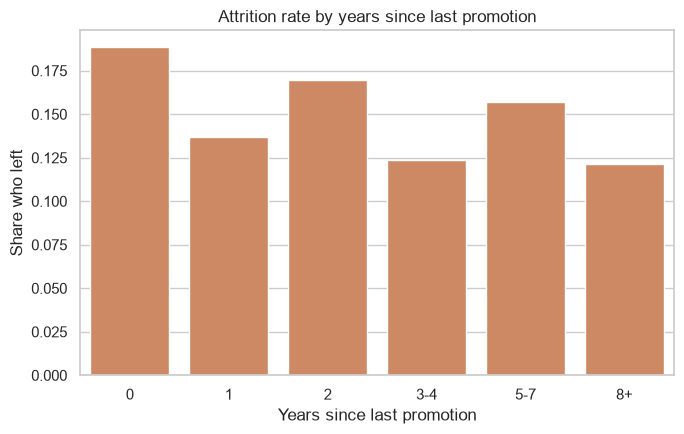

promo_bucket
0      0.189
1      0.137
2      0.170
3-4    0.124
5-7    0.157
8+     0.121
Name: Attrition, dtype: float64

promo_bucket
0      583
1      358
2      159
3-4    113
5-7    153
8+     107
Name: count, dtype: int64


In [11]:
promo_bins = [-1, 0, 1, 2, 4, 7, 100]
promo_labels = ["0", "1", "2", "3-4", "5-7", "8+"]
df_clean["promo_bucket"] = pd.cut(df_clean["YearsSinceLastPromotion"], bins=promo_bins, labels=promo_labels)

promo_attrition = (
    df_clean.groupby("promo_bucket", observed=True)["Attrition"]
    .apply(lambda s: (s == "Yes").mean())
)

plt.figure(figsize=(7, 4.5))
sns.barplot(x=promo_attrition.index, y=promo_attrition.values, color="#DD8452")
plt.title("Attrition rate by years since last promotion")
plt.xlabel("Years since last promotion")
plt.ylabel("Share who left")
plt.tight_layout()
plt.show()

print(promo_attrition.round(3))
print()
print(df_clean["promo_bucket"].value_counts().sort_index())

**EDA insights.**
- The target class distribution is imbalanced (approximately 84% `No`, 16% `Yes`); accuracy is therefore not used as the sole evaluation metric — precision, recall, F1, and ROC-AUC are reported, and `class_weight="balanced"` is applied as an initial mitigation in subsequent models.
- Missing values are restricted to `YearsWithCurrManager` (57 records). A data-entry inconsistency was identified in `BusinessTravel`, where `"TravelRarely"` and `"Travel_Rarely"` denote the same category (7 and 1,038 records respectively); these were consolidated during data cleaning.
- `MonthlyIncome` and `TotalWorkingYears` are lower among employees who left the organization, consistent with the significance tests reported above.
- Overtime is associated with a substantially higher attrition rate.
- Attrition rate varies substantially by job role: `Sales Representative` (39.3%) and `Laboratory Technician` (23.8%) exhibit the highest rates, while managerial and director roles — `Manager` (4.9%), `Research Director` (2.5%), `Manufacturing Director` (6.9%) — exhibit rates 5 to 16 times lower. A retention policy restricted to managerial or senior employees would therefore fail to reach the population where attrition risk concentrates (quantified in the Feature Engineering section below).
- Tenure exhibits a pronounced early-career effect: attrition rate declines from 34.9% in year 0–1 to 21.3% (year 1–2), 15.6% (2–3), 13.0% (3–5), 12.2% (5–10), and 8.1% (10+). Median tenure at departure ranges from 1 year (`Sales Representative`) and 2 years (`Laboratory Technician`) to 6–10 years for `Sales Executive`, `Manufacturing Director`, `Healthcare Representative`, and `Manager`; roles with the highest overall attrition also exhibit the shortest tenure at departure. Departures observed at longer tenure (`Manager`, median 10 years, n=5; `Research Director`, median 26.5 years, n=2) are based on small samples and are not generalized further.
- Frequent business travel is associated with elevated attrition across most roles: for `Sales Representative`, the rate increases from 32.1% (rare travel) to 65.2% (frequent travel), the highest value observed in the role-by-travel breakdown; comparable increases are observed for `Human Resources` and `Research Scientist`. No increase is observed for `Manager` or `Research Director`, though the frequent-travel subgroup for these roles is small (n=12–13) and any conclusion is correspondingly limited.
- `MaritalStatus = Single` is associated with elevated attrition for both genders, with comparable effect sizes (male: 26.9% vs. 12.6%; female: 23.5% vs. 10.3%; both p < 0.001). Given the similarity in effect size across genders, this is interpreted as a general association rather than a gender-specific interaction; a `Gender × MaritalStatus` interaction feature was not pursued on this basis.
- Time since last promotion does not exhibit a monotonic relationship with attrition rate when examined univariately (18.9%, 13.7%, 17.0%, 12.4%, 15.7%, 12.1% across successive year buckets). This is consistent with the earlier finding that `promotion_stagnation_ratio` was not statistically significant; the modest effect of `YearsSinceLastPromotion` observed in the multivariate model (Feature Importance section) is not evident in the univariate breakdown.
- The correlation matrix confirms a tenure-related feature cluster (`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, `TotalWorkingYears`), relevant to multicollinearity in linear models.

## Feature Engineering: Retention Priority

A business rule proposed earlier in this project restricted retention outreach to employees in managerial roles or with tenure exceeding three years. The EDA findings above indicate that applying this rule as a filter on model input or output would be counterproductive: managerial roles exhibit the lowest attrition rates, so restricting outreach accordingly would exclude a substantial share of actual departures (quantified below).

An alternative formulation is adopted: `is_priority_employee` (managerial role or tenure exceeding three years) is encoded as an input feature rather than an exclusion filter, allowing the model to weight it alongside other predictors. Predicted risk and retention value are distinct quantities; using the latter to filter model input discards information relevant to risk estimation. The two are kept separate: the model estimates risk, and `is_priority_employee` is included as one additional predictor.

In [12]:
managerial_roles = ["Manager", "Manufacturing Director", "Research Director"]
df_clean["is_priority_employee"] = (
    df_clean["JobRole"].isin(managerial_roles) | (df_clean["YearsAtCompany"] > 3)
).astype(int)

print(df_clean["is_priority_employee"].value_counts())
print()
print("Attrition rate by is_priority_employee:")
print(df_clean.groupby("is_priority_employee")["Attrition"].apply(lambda s: (s == "Yes").mean()).round(3))
print()

leavers = df_clean[df_clean["Attrition"] == "Yes"]
covered = leavers["is_priority_employee"].mean()
print(f"Share of actual leavers who ARE 'priority' employees: {covered:.1%}")
print(f"-> a rule that only contacts priority employees would miss {1 - covered:.1%} of real leavers -- "
      f"this is why it stays a model feature, not a hard filter on predictions.")

is_priority_employee
1    1066
0     407
Name: count, dtype: int64

Attrition rate by is_priority_employee:
is_priority_employee
0    0.292
1    0.111
Name: Attrition, dtype: float64

Share of actual leavers who ARE 'priority' employees: 49.8%
-> a rule that only contacts priority employees would miss 50.2% of real leavers -- this is why it stays a model feature, not a hard filter on predictions.


## Train/Test Split

The train/test partition is fixed here, before the feature-selection step below, and reused unchanged for the rest of the notebook (preprocessing, tuning, threshold selection, final pipeline). Deciding which engineered features to keep by testing their significance against the full dataset -- including rows that will later become the test set -- would let the test set influence a modeling decision before the model is ever evaluated on it. Splitting first avoids that: the candidate-feature significance tests below use `df_clean.loc[train_idx]` only.

In [13]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    df_clean.index, test_size=0.2, random_state=42,
    stratify=df_clean["Attrition"],
)

print(f"Train rows: {len(train_idx)}   Test rows: {len(test_idx)}")
print(f"Train Attrition rate: {(df_clean.loc[train_idx, 'Attrition'] == 'Yes').mean():.3f}   "
      f"Test Attrition rate: {(df_clean.loc[test_idx, 'Attrition'] == 'Yes').mean():.3f}")

Train rows: 1178   Test rows: 295
Train Attrition rate: 0.161   Test Attrition rate: 0.159


### Additional Candidate Features

Candidate engineered features were evaluated for statistical association with the target prior to inclusion, using the same procedure applied to the original dataset (Welch's t-test, `Attrition`-stratified) -- computed on the training partition (`train_idx`) established above, not the full dataset, so this feature-selection decision cannot be influenced by the held-out test set. Only features exhibiting a significant association were retained. Candidates evaluated:

- `job_hopping_ratio` = `NumCompaniesWorked / TotalWorkingYears`: a relative measure of employer-switching frequency, distinct from raw company count, which conflates job-switching behavior with career length.
- `manager_stability_ratio` = `YearsWithCurrManager / YearsAtCompany`: the proportion of tenure spent under the current manager.
- `satisfaction_composite` = mean of `EnvironmentSatisfaction`, `JobSatisfaction`, `RelationshipSatisfaction`, `WorkLifeBalance`, `JobInvolvement`: a composite index aggregating five ordinal satisfaction measures.
- `is_new_hire` = `YearsAtCompany <= 1`: an explicit encoding of the early-tenure effect identified above, capturing a relationship that a linear model cannot infer directly from `YearsAtCompany`.
- `promotion_stagnation_ratio` = `YearsSinceLastPromotion / YearsAtCompany`: tests whether promotion stagnation relative to tenure is more informative than the raw count.
- `income_relative_to_joblevel` = `MonthlyIncome / median(MonthlyIncome)` within `JobLevel`: tests whether income relative to job-level peers is more informative than absolute income.

In [14]:
y_flag = (df_clean["Attrition"] == "Yes").astype(int)

job_hopping_ratio = df_clean["NumCompaniesWorked"] / df_clean["TotalWorkingYears"].replace(0, np.nan)
job_hopping_ratio = job_hopping_ratio.fillna(0)

manager_stability_ratio = df_clean["YearsWithCurrManager"] / df_clean["YearsAtCompany"].replace(0, np.nan)
manager_stability_ratio = manager_stability_ratio.fillna(0)

satisfaction_cols = ["EnvironmentSatisfaction", "JobSatisfaction", "RelationshipSatisfaction",
                      "WorkLifeBalance", "JobInvolvement"]
satisfaction_composite = df_clean[satisfaction_cols].mean(axis=1)

is_new_hire = (df_clean["YearsAtCompany"] <= 1).astype(int)

promotion_stagnation_ratio = df_clean["YearsSinceLastPromotion"] / df_clean["YearsAtCompany"].replace(0, np.nan)
promotion_stagnation_ratio = promotion_stagnation_ratio.fillna(0)

# Group medians for this candidate are computed from the training rows only -- using
# test-set incomes here would leak test data into a feature-selection decision, even
# though the feature itself ends up excluded below.
train_job_level_median = df_clean.loc[train_idx].groupby("JobLevel")["MonthlyIncome"].median()
income_relative_to_joblevel = df_clean["MonthlyIncome"] / df_clean["JobLevel"].map(train_job_level_median)

candidates = {
    "job_hopping_ratio": job_hopping_ratio,
    "manager_stability_ratio": manager_stability_ratio,
    "satisfaction_composite": satisfaction_composite,
    "is_new_hire": is_new_hire,
    "promotion_stagnation_ratio": promotion_stagnation_ratio,
    "income_relative_to_joblevel": income_relative_to_joblevel,
}

# Significance is assessed on the training rows only (train_idx) -- the test set must
# not influence which features are selected for the model.
y_flag_train = y_flag.loc[train_idx]

print(f"{'Feature':30s} {'mean(Yes)':>10s} {'mean(No)':>10s} {'p-value':>12s}  (train rows only, n={len(train_idx)})")
for name, series in candidates.items():
    series_train = series.loc[train_idx]
    t_stat, p_value = stats.ttest_ind(series_train[y_flag_train == 1], series_train[y_flag_train == 0], equal_var=False)
    print(f"{name:30s} {series_train[y_flag_train==1].mean():10.3f} {series_train[y_flag_train==0].mean():10.3f} {p_value:12.2e}")

Feature                         mean(Yes)   mean(No)      p-value  (train rows only, n=1178)
job_hopping_ratio                   0.520      0.294     1.98e-08
manager_stability_ratio             0.443      0.547     6.48e-04
satisfaction_composite              2.575      2.770     1.97e-07
is_new_hire                         0.311      0.120     1.70e-07
promotion_stagnation_ratio          0.317      0.284     2.54e-01
income_relative_to_joblevel         0.979      1.033     9.57e-03


**Findings.** Four candidates exhibit a statistically significant association with `Attrition` on the training partition (p < 0.05) and were retained: `job_hopping_ratio` (p ≈ 2.0×10⁻⁸), `is_new_hire` (p ≈ 1.7×10⁻⁷), `satisfaction_composite` (p ≈ 2.0×10⁻⁷), and `manager_stability_ratio` (p ≈ 6.5×10⁻⁴).

Two candidates were excluded. `promotion_stagnation_ratio` showed no significant effect (p ≈ 0.25), indicating that the relative-to-tenure formulation does not add information beyond `YearsSinceLastPromotion`. `income_relative_to_joblevel` was significant at the conventional 0.05 threshold (p ≈ 0.0096) but strongly correlated with `MonthlyIncome`, the strongest numeric predictor in the dataset; it was excluded on multicollinearity grounds rather than on significance, since retaining both would add redundancy without a corresponding benefit.

In [15]:
df_clean["job_hopping_ratio"] = job_hopping_ratio
df_clean["manager_stability_ratio"] = manager_stability_ratio
df_clean["satisfaction_composite"] = satisfaction_composite
df_clean["is_new_hire"] = is_new_hire

new_feature_cols = ["job_hopping_ratio", "manager_stability_ratio", "satisfaction_composite", "is_new_hire"]
print(f"Added features: {new_feature_cols}")
print(f"df_clean shape: {df_clean.shape}")
print(df_clean[new_feature_cols].describe().round(3))

Added features: ['job_hopping_ratio', 'manager_stability_ratio', 'satisfaction_composite', 'is_new_hire']
df_clean shape: (1473, 40)
       job_hopping_ratio  manager_stability_ratio  satisfaction_composite  \
count           1473.000                 1473.000                1473.000   
mean               0.333                    0.536                   2.731   
std                0.375                    0.346                   0.429   
min                0.000                    0.000                   1.200   
25%                0.100                    0.250                   2.400   
50%                0.200                    0.625                   2.800   
75%                0.444                    0.800                   3.000   
max                3.000                    1.250                   4.000   

       is_new_hire  
count     1473.000  
mean         0.146  
std          0.353  
min          0.000  
25%          0.000  
50%          0.000  
75%          0.000  
max  

## Baseline Preprocessing

A leakage-safe procedure is applied: the train/test partition established above is reused directly (no re-splitting), and imputation, encoding, and scaling parameters are derived from the training rows only. This baseline establishes a reference point prior to hyperparameter tuning and threshold optimization; Section 8 assembles the complete preprocessing-plus-model pipeline as a single deployable object.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

y = df_clean["Attrition"].map({"No": 0, "Yes": 1})
# tenure_bucket / promo_bucket were created only for the EDA charts above -- they are
# binned duplicates of YearsAtCompany / YearsSinceLastPromotion, which are already
# numeric features here, so keeping both would just add redundant multicollinearity.
eda_only_cols = ["tenure_bucket", "promo_bucket"]
X = df_clean.drop(columns=["Attrition"] + [c for c in eda_only_cols if c in df_clean.columns])

# Reuse the exact train/test partition established before feature selection above,
# rather than re-splitting -- keeps a single source of truth for which rows are
# "test" throughout the notebook.
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"Train Attrition rate: {y_train.mean():.3f}   Test Attrition rate: {y_test.mean():.3f}")

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
        ]), categorical_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"Missing values remaining: {np.isnan(X_train_processed).sum()} (train), "
      f"{np.isnan(X_test_processed).sum()} (test)")

X_train: (1178, 37)   X_test: (295, 37)


Train Attrition rate: 0.161   Test Attrition rate: 0.159


X_train_processed shape: (1178, 56)


X_test_processed shape: (295, 56)
Missing values remaining: 0 (train), 0 (test)


## Baseline Model Training and Evaluation

Five classifiers were evaluated on identical processed features, spanning a range of model complexity: decision tree (single-tree baseline), k-nearest neighbors (distance-based), logistic regression (linear), and two tree ensembles, random forest and gradient boosting. `class_weight="balanced"` was applied where supported to address the approximately 84/16 class imbalance; gradient boosting does not expose this parameter in scikit-learn and was evaluated without it.

Evaluation metrics were accuracy, precision/recall/F1 on the minority class, ROC-AUC, and confusion matrices. The strongest-performing models were subsequently carried forward for hyperparameter and threshold optimization.

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

baseline_models = {
    "DecisionTree": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),  # class_weight not supported in sklearn
}

fitted_models = {}
for name, model in baseline_models.items():
    model.fit(X_train_processed, y_train)
    fitted_models[name] = model
    y_pred = model.predict(X_test_processed)

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))
    print("Confusion matrix (rows=actual, cols=predicted):")
    print(confusion_matrix(y_test, y_pred))
    print()

=== DecisionTree ===
              precision    recall  f1-score   support

          No       0.92      0.84      0.88       248
         Yes       0.41      0.60      0.49        47

    accuracy                           0.80       295
   macro avg       0.66      0.72      0.68       295
weighted avg       0.84      0.80      0.81       295

Confusion matrix (rows=actual, cols=predicted):
[[208  40]
 [ 19  28]]



=== KNN ===
              precision    recall  f1-score   support

          No       0.86      1.00      0.92       248
         Yes       1.00      0.11      0.19        47

    accuracy                           0.86       295
   macro avg       0.93      0.55      0.56       295
weighted avg       0.88      0.86      0.81       295

Confusion matrix (rows=actual, cols=predicted):
[[248   0]
 [ 42   5]]

=== LogisticRegression ===
              precision    recall  f1-score   support

          No       0.97      0.77      0.86       248
         Yes       0.43      0.89      0.58        47

    accuracy                           0.79       295
   macro avg       0.70      0.83      0.72       295
weighted avg       0.89      0.79      0.82       295

Confusion matrix (rows=actual, cols=predicted):
[[192  56]
 [  5  42]]



=== RandomForest ===
              precision    recall  f1-score   support

          No       0.93      0.92      0.93       248
         Yes       0.61      0.66      0.63        47

    accuracy                           0.88       295
   macro avg       0.77      0.79      0.78       295
weighted avg       0.88      0.88      0.88       295

Confusion matrix (rows=actual, cols=predicted):
[[228  20]
 [ 16  31]]



=== GradientBoosting ===
              precision    recall  f1-score   support

          No       0.91      0.97      0.94       248
         Yes       0.73      0.47      0.57        47

    accuracy                           0.89       295
   macro avg       0.82      0.72      0.75       295
weighted avg       0.88      0.89      0.88       295

Confusion matrix (rows=actual, cols=predicted):
[[240   8]
 [ 25  22]]



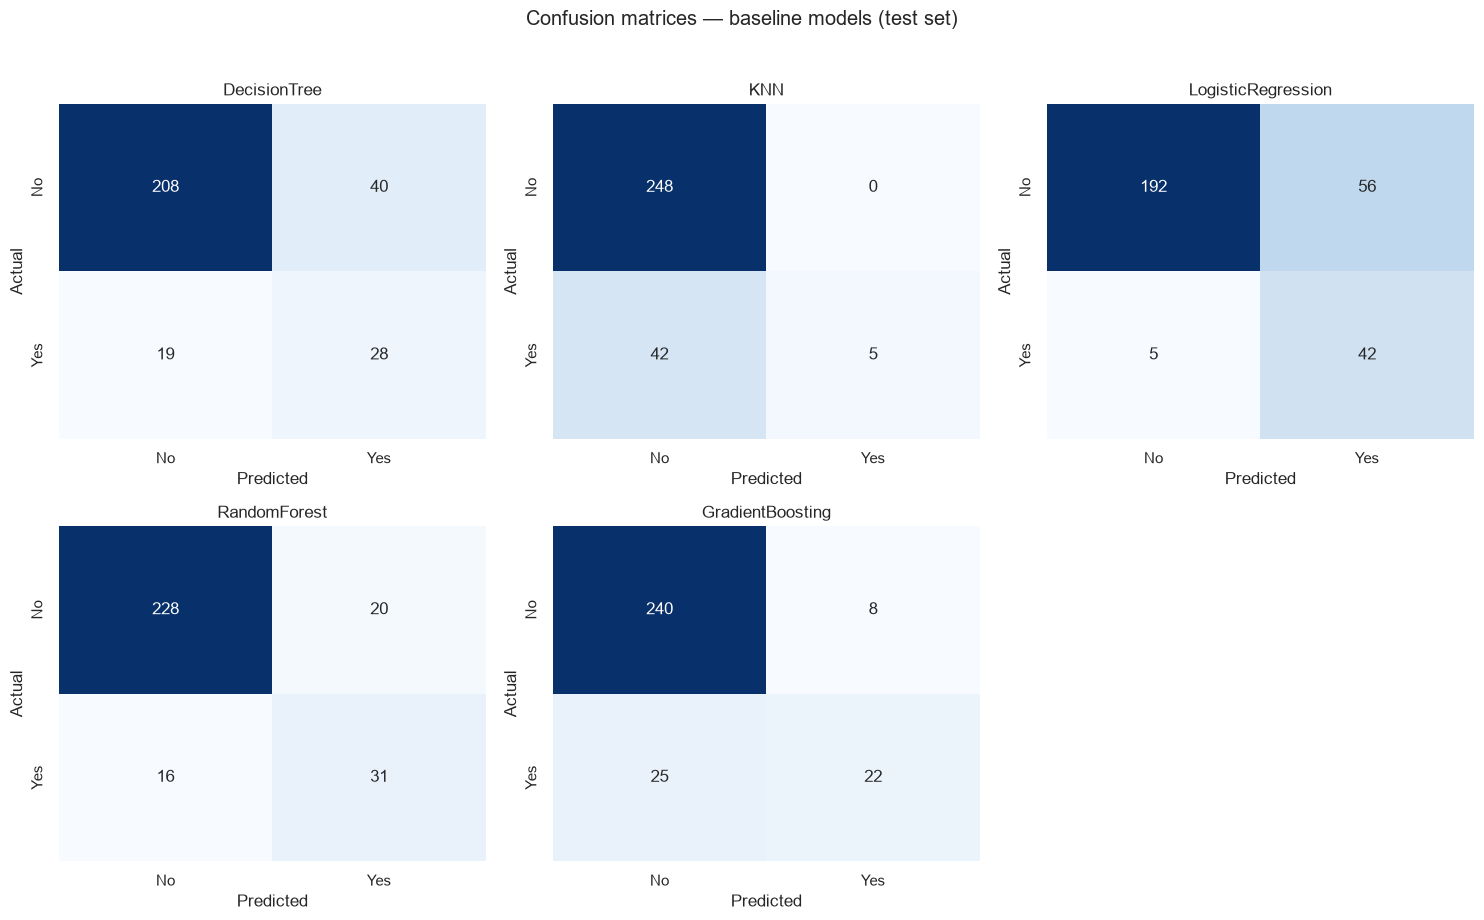

In [18]:
cm_fig, cm_axes = plt.subplots(2, 3, figsize=(15, 9))
cm_axes = cm_axes.ravel()

for ax, (name, model) in zip(cm_axes, fitted_models.items()):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["No", "Yes"], yticklabels=["No", "Yes"], ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in cm_axes[len(fitted_models):]:
    ax.axis("off")

plt.suptitle("Confusion matrices — baseline models (test set)", y=1.02)
plt.tight_layout()
plt.show()

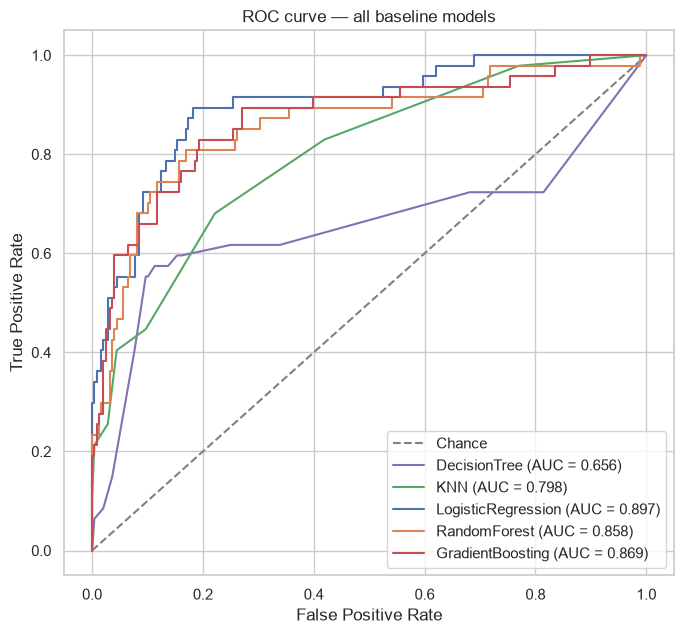

In [19]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6.5))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")

# Fixed categorical color per model identity (never cycled/reused for a different model).
roc_colors = {
    "DecisionTree": "#8172B2",
    "KNN": "#55A868",
    "LogisticRegression": "#4C72B0",
    "RandomForest": "#DD8452",
    "GradientBoosting": "#C44E52",
}
for name, model in fitted_models.items():
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=roc_colors[name], label=f"{name} (AUC = {auc:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — all baseline models")
plt.legend()
plt.tight_layout()
plt.show()

**Baseline results.**
- Ranked by test ROC-AUC: logistic regression (0.897), gradient boosting (0.869), random forest (0.858), k-nearest neighbors (0.798), decision tree (0.656). The engineered features (Section 3) improved every model relative to a version without them; random forest showed the largest gain, from AUC 0.821 to 0.858, and attained the highest F1 among all five models (0.63).
- Logistic regression exhibits the highest recall on `Attrition = Yes` (0.89), attributable to `class_weight="balanced"`, at the lowest precision (0.43) among the five models.
- Random forest exhibits the most balanced precision/recall trade-off (precision 0.61, recall 0.66) among the untuned models.
- k-nearest neighbors exhibits 100% precision but 11% recall, indicating that predictions are dominated by the majority class.
- Random forest and logistic regression were selected for hyperparameter tuning prior to this five-model comparison being available. Gradient boosting (AUC 0.869) outperforms random forest (AUC 0.858) by this metric despite random forest's higher F1, and was subsequently included in tuning as well (Section 5).

## Hyperparameter Tuning

The three strongest baseline models were tuned using 5-fold stratified cross-validation on the training set, with the test set held out until final evaluation. ROC-AUC was used as the optimization criterion, as a threshold-independent measure appropriate given that the decision threshold is treated as a separate parameter (Sections 6–7).

- Random forest: `RandomizedSearchCV` over `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features` (30 sampled combinations).
- Logistic regression: `GridSearchCV` over the regularization parameter `C` (exhaustive search, given the small parameter space).
- Gradient boosting: `RandomizedSearchCV` over `n_estimators`, `learning_rate`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `subsample` (30 sampled combinations).

In [20]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_param_grid = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5],
}
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train_processed, y_train)

logreg_param_grid = {"C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]}
logreg_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    param_grid=logreg_param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
logreg_search.fit(X_train_processed, y_train)

print("RandomForest best params:", rf_search.best_params_)
print(f"RandomForest best CV ROC-AUC: {rf_search.best_score_:.4f}")
print()
print("LogisticRegression best params:", logreg_search.best_params_)
print(f"LogisticRegression best CV ROC-AUC: {logreg_search.best_score_:.4f}")

gb_param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.7, 0.85, 1.0],
}
gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
)
gb_search.fit(X_train_processed, y_train)

print("GradientBoosting best params:", gb_search.best_params_)
print(f"GradientBoosting best CV ROC-AUC: {gb_search.best_score_:.4f}")

tuned_models = {
    "RandomForest_tuned": rf_search.best_estimator_,
    "LogisticRegression_tuned": logreg_search.best_estimator_,
    "GradientBoosting_tuned": gb_search.best_estimator_,
}

RandomForest best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
RandomForest best CV ROC-AUC: 0.7985

LogisticRegression best params: {'C': 0.1}
LogisticRegression best CV ROC-AUC: 0.8088


GradientBoosting best params: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.03}
GradientBoosting best CV ROC-AUC: 0.8177


In [21]:
baseline_test_auc = {
    name: roc_auc_score(y_test, model.predict_proba(X_test_processed)[:, 1])
    for name, model in fitted_models.items()
}

print("=== Test-set evaluation: tuned models ===\n")
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))
    print(f"Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
    print()

print("=== Baseline vs tuned: test ROC-AUC ===")
print(f"LogisticRegression : baseline={baseline_test_auc['LogisticRegression']:.4f}  "
      f"tuned={roc_auc_score(y_test, tuned_models['LogisticRegression_tuned'].predict_proba(X_test_processed)[:, 1]):.4f}")
print(f"RandomForest        : baseline={baseline_test_auc['RandomForest']:.4f}  "
      f"tuned={roc_auc_score(y_test, tuned_models['RandomForest_tuned'].predict_proba(X_test_processed)[:, 1]):.4f}")
print(f"GradientBoosting    : baseline={baseline_test_auc['GradientBoosting']:.4f}  "
      f"tuned={roc_auc_score(y_test, tuned_models['GradientBoosting_tuned'].predict_proba(X_test_processed)[:, 1]):.4f}")

=== Test-set evaluation: tuned models ===



--- RandomForest_tuned ---
              precision    recall  f1-score   support

          No       0.90      0.96      0.93       248
         Yes       0.69      0.43      0.53        47

    accuracy                           0.88       295
   macro avg       0.79      0.69      0.73       295
weighted avg       0.87      0.88      0.87       295

Test ROC-AUC: 0.8516

--- LogisticRegression_tuned ---
              precision    recall  f1-score   support

          No       0.97      0.79      0.87       248
         Yes       0.44      0.87      0.59        47

    accuracy                           0.80       295
   macro avg       0.71      0.83      0.73       295
weighted avg       0.89      0.80      0.83       295

Test ROC-AUC: 0.8985

--- GradientBoosting_tuned ---
              precision    recall  f1-score   support

          No       0.92      0.99      0.95       248
         Yes       0.93      0.53      0.68        47

    accuracy                           0.92    

RandomForest        : baseline=0.8580  tuned=0.8516
GradientBoosting    : baseline=0.8686  tuned=0.8666


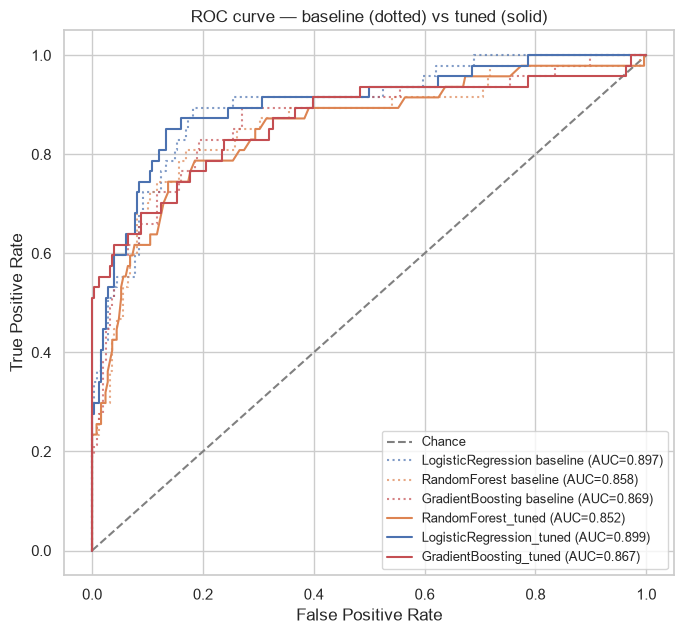

In [22]:
plt.figure(figsize=(7, 6.5))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")

# Only the two models that were actually carried into tuning are compared here
# (the full five-model sweep is in the baseline section above).
model_colors = {"LogisticRegression": "#4C72B0", "RandomForest": "#DD8452", "GradientBoosting": "#C44E52"}
for base_name in model_colors:
    base_model = fitted_models[base_name]
    fpr, tpr, _ = roc_curve(y_test, base_model.predict_proba(X_test_processed)[:, 1])
    auc = baseline_test_auc[base_name]
    plt.plot(fpr, tpr, color=model_colors[base_name], linestyle=":", alpha=0.7,
              label=f"{base_name} baseline (AUC={auc:.3f})")

for tuned_name, tuned_model in tuned_models.items():
    base_name = tuned_name.replace("_tuned", "")
    fpr, tpr, _ = roc_curve(y_test, tuned_model.predict_proba(X_test_processed)[:, 1])
    auc = roc_auc_score(y_test, tuned_model.predict_proba(X_test_processed)[:, 1])
    plt.plot(fpr, tpr, color=model_colors[base_name], linestyle="-",
              label=f"{tuned_name} (AUC={auc:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — baseline (dotted) vs tuned (solid)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Tuning results.**
- Random forest: cross-validated ROC-AUC ≈ 0.799; test ROC-AUC decreased from 0.858 (baseline) to 0.852 (tuned).
- Logistic regression: best parameter `C = 0.1`; cross-validated ROC-AUC ≈ 0.809; test ROC-AUC increased marginally from 0.897 to 0.899.
- Gradient boosting: best configuration used a shallow maximum depth (3) and a low learning rate (0.03) with a larger number of estimators; cross-validated ROC-AUC ≈ 0.818, the highest of the three models, but test ROC-AUC decreased from 0.869 (baseline) to 0.867 (tuned). As with random forest, an improved cross-validated score did not correspond to an improved test-set score.
- Tuned gradient boosting attained the highest precision and F1 among all models evaluated at the default threshold (precision 0.93, recall 0.53, F1 0.68 on `Attrition = Yes`), with approximately two false positives across the entire test set, at the cost of recall.
- Logistic regression retains the highest test ROC-AUC (0.899). Model selection at this stage depends on the intended use case: logistic regression maximizes recall, tuned gradient boosting minimizes false positives, and the random-forest baseline provides an intermediate trade-off (F1 = 0.63).
- This single-split observation is tested directly below: repeated stratified splits are used to check whether the baseline-vs-tuned gap is distinguishable from resampling noise, or is itself an artifact of this particular `random_state=42` split.

### Repeated-Split Robustness Check

The tuning results above are based on a single train/test partition (`random_state=42`). With a 295-row test set, a small shift in which rows land in the test fold can plausibly move ROC-AUC by more than the ≈0.001-0.006 gaps observed between baseline and tuned models. This is tested directly: the exact model configurations found by the single-split search above (`rf_search.best_estimator_`, `logreg_search.best_estimator_`, `gb_search.best_estimator_`) are compared against their untuned baseline counterparts across 20 independent stratified train/test splits, refitting the preprocessor and both models fresh on each split's training rows only.

This does **not** re-run hyperparameter search on each split -- that would answer a different question ("would tuning find similar hyperparameters on other data"). It answers the narrower question the conclusion actually depends on: for these specific already-tuned configurations, is the observed test-AUC advantage over the baseline real, or is it within the noise band produced by resampling alone?

In [23]:
from sklearn.base import clone

N_REPEATS = 20

baseline_configs = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=8, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}
tuned_configs = {
    "RandomForest": rf_search.best_estimator_,
    "LogisticRegression": logreg_search.best_estimator_,
    "GradientBoosting": gb_search.best_estimator_,
}

repeated_records = []
for seed in range(N_REPEATS):
    tr_idx, te_idx = train_test_split(
        df_clean.index, test_size=0.2, random_state=seed, stratify=df_clean["Attrition"]
    )
    X_tr, X_te = X.loc[tr_idx], X.loc[te_idx]
    y_tr, y_te = y.loc[tr_idx], y.loc[te_idx]

    # Fresh preprocessor per split, fit on that split's training rows only --
    # same leakage-safe rule applied everywhere else in this notebook.
    prep = clone(preprocessor)
    X_tr_proc = prep.fit_transform(X_tr)
    X_te_proc = prep.transform(X_te)

    for name in baseline_configs:
        base_model = clone(baseline_configs[name])
        base_model.fit(X_tr_proc, y_tr)
        base_auc = roc_auc_score(y_te, base_model.predict_proba(X_te_proc)[:, 1])

        tuned_model = clone(tuned_configs[name])
        tuned_model.fit(X_tr_proc, y_tr)
        tuned_auc = roc_auc_score(y_te, tuned_model.predict_proba(X_te_proc)[:, 1])

        repeated_records.append({
            "Model": name, "Split_seed": seed,
            "Baseline_AUC": base_auc, "Tuned_AUC": tuned_auc, "Diff": tuned_auc - base_auc,
        })

repeated_df = pd.DataFrame(repeated_records)

summary_rows = []
for name, sub in repeated_df.groupby("Model"):
    diffs = sub["Diff"].values
    mean_diff = diffs.mean()
    se = diffs.std(ddof=1) / np.sqrt(len(diffs))
    ci_low, ci_high = mean_diff - 1.96 * se, mean_diff + 1.96 * se
    t_stat, p_value = stats.ttest_rel(sub["Tuned_AUC"], sub["Baseline_AUC"])
    summary_rows.append({
        "Model": name,
        "Mean baseline AUC": sub["Baseline_AUC"].mean(),
        "Mean tuned AUC": sub["Tuned_AUC"].mean(),
        "Mean diff (tuned-baseline)": mean_diff,
        "95% CI low": ci_low, "95% CI high": ci_high,
        "Paired t p-value": p_value,
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model")
pd.set_option("display.width", 160)
print(f"Repeated stratified splits: {N_REPEATS} (seeds 0-{N_REPEATS-1}), "
      f"same model configurations as the single-split tuning above.\n")
print(summary_df.round(4).to_string())

Repeated stratified splits: 20 (seeds 0-19), same model configurations as the single-split tuning above.

                    Mean baseline AUC  Mean tuned AUC  Mean diff (tuned-baseline)  95% CI low  95% CI high  Paired t p-value
Model                                                                                                                       
GradientBoosting               0.8082          0.8174                      0.0091      0.0039       0.0143            0.0028
LogisticRegression             0.8364          0.8367                      0.0003     -0.0031       0.0037            0.8632
RandomForest                   0.8035          0.8060                      0.0025     -0.0022       0.0072            0.3113


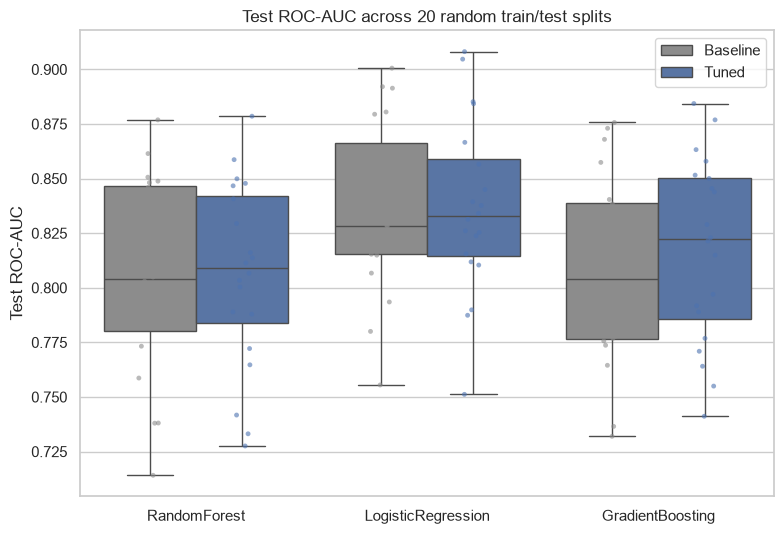

In [24]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_df = repeated_df.melt(id_vars=["Model", "Split_seed"], value_vars=["Baseline_AUC", "Tuned_AUC"],
                            var_name="Variant", value_name="Test_AUC")
plot_df["Variant"] = plot_df["Variant"].str.replace("_AUC", "", regex=False)

sns.boxplot(data=plot_df, x="Model", y="Test_AUC", hue="Variant",
            palette={"Baseline": "#8C8C8C", "Tuned": "#4C72B0"}, ax=ax)
sns.stripplot(data=plot_df, x="Model", y="Test_AUC", hue="Variant", dodge=True,
              palette={"Baseline": "#8C8C8C", "Tuned": "#4C72B0"}, alpha=0.6, size=3.5,
              legend=False, ax=ax)

ax.set_title(f"Test ROC-AUC across {N_REPEATS} random train/test splits")
ax.set_ylabel("Test ROC-AUC")
ax.set_xlabel("")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="")
plt.tight_layout()
plt.show()

**Robustness check findings.**
- Test-set ROC-AUC varies substantially across splits -- roughly 0.72-0.90 for random forest, 0.75-0.91 for logistic regression, 0.73-0.88 for gradient boosting -- a spread far larger than any of the baseline-vs-tuned gaps reported on the single split above. This confirms the estimation-variance explanation directly rather than merely inferring it from a cross-validated-vs-test discrepancy.
- For logistic regression (mean diff +0.0003, 95% CI [-0.0031, 0.0037], paired t p=0.86) and random forest (mean diff +0.0025, 95% CI [-0.0022, 0.0072], p=0.31), the tuned-vs-baseline gap is statistically indistinguishable from zero across 20 splits -- the single-split conclusion that tuning didn't help (or slightly hurt) these two models is one plausible draw from a distribution centered near zero, not a reliable model property.
- Gradient boosting is the exception: tuning produces a small but statistically significant improvement (mean diff +0.0091 AUC, 95% CI [0.0039, 0.0143], paired t p=0.0028) -- the 95% CI excludes zero. This *revises* the single-split finding reported above, where tuned gradient boosting appeared to underperform its baseline (0.869 -> 0.867); that comparison happened to land on an unfavorable split. Averaged over resampling, tuning gradient boosting is worth it.
- The mean baseline AUCs here (0.80-0.84) are also noticeably lower than the single-split baseline AUCs reported earlier (0.86-0.90), illustrating the same point from the other direction: the original `random_state=42` split was, by chance, a comparatively favorable one for all three models. Single-split test metrics on a dataset this size should be read as one sample from a wide distribution, not a precise estimate.

## Decision Threshold Tuning

The default classification threshold of 0.5 is not derived from the cost structure of the problem: for a retention use case, a false negative (an employee who leaves without being identified) is typically more costly than a false positive (an unnecessary retention conversation). A threshold was selected by maximizing F1 on out-of-fold predictions from the training set (via `cross_val_predict`) and applied once to the held-out test set, avoiding threshold selection on test data.

In [25]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

best_model = tuned_models["RandomForest_tuned"]

oof_probs = cross_val_predict(best_model, X_train_processed, y_train, cv=cv, method="predict_proba")[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"F1-optimal threshold (out-of-fold, train only): {best_threshold:.3f}")
print(f"  OOF precision={precisions[best_idx]:.3f}  recall={recalls[best_idx]:.3f}  F1={f1_scores[best_idx]:.3f}")

# Apply the chosen threshold exactly once, to the untouched test set.
test_probs = best_model.predict_proba(X_test_processed)[:, 1]
y_pred_thresholded = (test_probs >= best_threshold).astype(int)

print(f"\n=== RandomForest_tuned @ threshold={best_threshold:.3f} (test set) ===")
print(classification_report(y_test, y_pred_thresholded, target_names=["No", "Yes"]))

F1-optimal threshold (out-of-fold, train only): 0.357
  OOF precision=0.455  recall=0.605  F1=0.519

=== RandomForest_tuned @ threshold=0.357 (test set) ===
              precision    recall  f1-score   support

          No       0.95      0.85      0.90       248
         Yes       0.49      0.74      0.59        47

    accuracy                           0.83       295
   macro avg       0.72      0.80      0.74       295
weighted avg       0.87      0.83      0.85       295



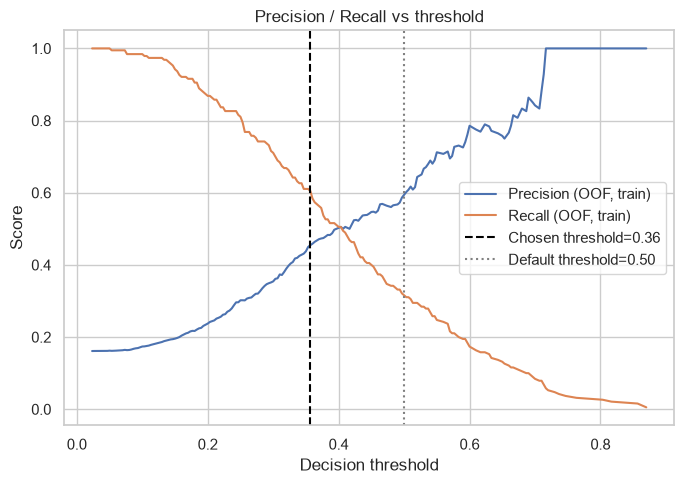

In [26]:
plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], color="#4C72B0", label="Precision (OOF, train)")
plt.plot(thresholds, recalls[:-1], color="#DD8452", label="Recall (OOF, train)")
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Chosen threshold={best_threshold:.2f}")
plt.axvline(0.5, color="gray", linestyle=":", label="Default threshold=0.50")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("Precision / Recall vs threshold")
plt.legend()
plt.tight_layout()
plt.show()

**Threshold tuning results.**
- The F1-optimal threshold on out-of-fold training predictions is approximately 0.36.
- Applied to the test set, random forest (tuned) at this threshold yields precision ≈ 0.49 and recall ≈ 0.74 on `Attrition = Yes`, compared to precision ≈ 0.69 and recall ≈ 0.43 at the default threshold — an increase in recall of approximately 1.7× at a corresponding reduction in precision.
- The appropriate operating point depends on the relative cost of a missed departure versus an unnecessary conversation; this is addressed directly in the F-beta and cost-ratio analysis below.

### F-beta Threshold Selection Across All Tuned Models

The three-model comparison in the preceding sections is not directly comparable across models, as each received different treatment: logistic regression incorporates `class_weight="balanced"` during training, random forest was explicitly threshold-tuned, and gradient boosting was evaluated at the untouched default threshold (it does not support `class_weight`). To enable a comparable evaluation, the same threshold-selection procedure — F-beta maximized on out-of-fold training predictions, applied once to the test set — is applied to all three tuned models under three criteria:

- F1 (β = 1): precision and recall weighted equally.
- F1.5 (β = 1.5) and F2 (β = 2): recall weighted more heavily, reflecting the assumption that a missed departure is costlier than an unnecessary conversation.
- A cost-ratio threshold: the Bayes-optimal cutoff `threshold = cost_FP / (cost_FP + cost_FN)`, using an estimated replacement cost of $30,000–$180,000 against an estimated conversation cost of $100, yielding a cost ratio of 300–1800×.

### Probability Calibration Check

The cost-ratio threshold computed below (`threshold = cost_FP / (cost_FP + cost_FN)`) is the Bayes-optimal cutoff only if `predict_proba` returns calibrated probabilities -- i.e., among cases predicted at probability *p*, roughly a fraction *p* actually belong to the positive class. Impurity-based tree ensembles (random forest, gradient boosting) are not calibrated by construction and often push probabilities toward the extremes; logistic regression is calibrated by construction when the linear model is reasonably well specified. This is checked directly below, using the same out-of-fold training predictions (leakage-safe, no test-set probabilities) as the threshold-selection procedure elsewhere in this notebook, before the cost-ratio numbers are interpreted at face value.

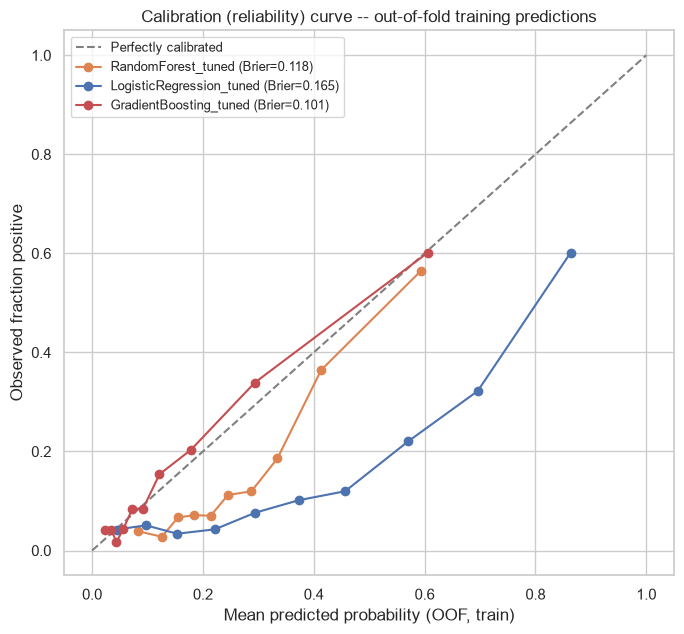

Brier score (lower = better calibrated, OOF train):
  GradientBoosting_tuned       0.1006
  RandomForest_tuned           0.1181
  LogisticRegression_tuned     0.1653


In [27]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")

calib_colors = {"LogisticRegression_tuned": "#4C72B0", "RandomForest_tuned": "#DD8452", "GradientBoosting_tuned": "#C44E52"}
brier_scores = {}
for model_name, model in tuned_models.items():
    oof_probs = cross_val_predict(model, X_train_processed, y_train, cv=cv, method="predict_proba")[:, 1]
    frac_pos, mean_pred = calibration_curve(y_train, oof_probs, n_bins=10, strategy="quantile")
    brier_scores[model_name] = brier_score_loss(y_train, oof_probs)
    ax.plot(mean_pred, frac_pos, marker="o", color=calib_colors[model_name],
            label=f"{model_name} (Brier={brier_scores[model_name]:.3f})")

ax.set_xlabel("Mean predicted probability (OOF, train)")
ax.set_ylabel("Observed fraction positive")
ax.set_title("Calibration (reliability) curve -- out-of-fold training predictions")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Brier score (lower = better calibrated, OOF train):")
for name, score in sorted(brier_scores.items(), key=lambda kv: kv[1]):
    print(f"  {name:28s} {score:.4f}")

**Calibration findings.**
- Random forest and gradient boosting (tuned) track the diagonal closely across the probability range (Brier = 0.118 and 0.101 respectively) -- their OOF predicted probabilities are a reasonable approximation of true likelihood, despite being impurity-based tree ensembles, which are not calibrated by construction in general.
- Logistic regression (tuned) is markedly miscalibrated in the opposite direction: at a mean predicted probability of ≈0.6 it flags cases that actually leave only ≈22% of the time, and at ≈0.86 predicted, the observed rate is only ≈60% (Brier = 0.165, the worst of the three). This is attributable to `class_weight="balanced"`, which reweights the training loss toward the minority class and shifts fitted probabilities upward without any compensating calibration step -- it is a property of the balanced reweighting, not of logistic regression itself.
- Practical implication for the cost-ratio threshold above: it is least trustworthy for logistic regression specifically, the model otherwise recommended for F-beta-based flagging. The degenerate result already reported (threshold near zero, entire workforce flagged) holds regardless of calibration quality, since it is driven by the extreme cost ratio itself (300--1800×) rather than by miscalibration. Were a cost-ratio threshold to be operationalized on real data, `CalibratedClassifierCV` (Platt or isotonic scaling) should be applied first, particularly to any class-weighted logistic regression model.

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

def fbeta_optimal_threshold(precisions, recalls, thresholds, beta):
    b2 = beta ** 2
    fbeta = (1 + b2) * precisions * recalls / (b2 * precisions + recalls + 1e-12)
    idx = np.argmax(fbeta[:-1])
    return thresholds[idx], fbeta[idx]


fbeta_results = []
for model_name, model in tuned_models.items():
    # Out-of-fold probabilities on train only -- same leakage-safe procedure as the F1 threshold above,
    # just repeated for every model instead of only Random Forest.
    oof_probs = cross_val_predict(model, X_train_processed, y_train, cv=cv, method="predict_proba")[:, 1]
    oof_precisions, oof_recalls, oof_thresholds = precision_recall_curve(y_train, oof_probs)
    test_probs = model.predict_proba(X_test_processed)[:, 1]

    for beta, label in [(1.0, "F1"), (1.5, "F1.5"), (2.0, "F2")]:
        threshold, _ = fbeta_optimal_threshold(oof_precisions, oof_recalls, oof_thresholds, beta)
        y_pred = (test_probs >= threshold).astype(int)
        fbeta_results.append({
            "Model": model_name, "Criterion": label, "Threshold": threshold,
            "Test_Precision": precision_score(y_test, y_pred, zero_division=0),
            "Test_Recall": recall_score(y_test, y_pred, zero_division=0),
            "Test_F1": f1_score(y_test, y_pred, zero_division=0),
            "Flagged_share": y_pred.mean(),
        })

    # Cost-ratio thresholds are computed directly from the formula, not searched for.
    for ratio, label in [(300, "Cost-ratio 300x"), (1800, "Cost-ratio 1800x")]:
        threshold = 1 / (1 + ratio)
        y_pred = (test_probs >= threshold).astype(int)
        fbeta_results.append({
            "Model": model_name, "Criterion": label, "Threshold": threshold,
            "Test_Precision": precision_score(y_test, y_pred, zero_division=0),
            "Test_Recall": recall_score(y_test, y_pred, zero_division=0),
            "Test_F1": f1_score(y_test, y_pred, zero_division=0),
            "Flagged_share": y_pred.mean(),
        })

fbeta_results_df = pd.DataFrame(fbeta_results)
pd.set_option("display.width", 160)
print(fbeta_results_df.round(4).to_string(index=False))

                   Model        Criterion  Threshold  Test_Precision  Test_Recall  Test_F1  Flagged_share
      RandomForest_tuned               F1     0.3567          0.4861       0.7447   0.5882         0.2441
      RandomForest_tuned             F1.5     0.3333          0.4500       0.7660   0.5669         0.2712
      RandomForest_tuned               F2     0.2433          0.3022       0.8936   0.4516         0.4712
      RandomForest_tuned  Cost-ratio 300x     0.0033          0.1593       1.0000   0.2749         1.0000
      RandomForest_tuned Cost-ratio 1800x     0.0006          0.1593       1.0000   0.2749         1.0000
LogisticRegression_tuned               F1     0.6593          0.6034       0.7447   0.6667         0.1966
LogisticRegression_tuned             F1.5     0.5069          0.4409       0.8723   0.5857         0.3153
LogisticRegression_tuned               F2     0.4563          0.4141       0.8723   0.5616         0.3356
LogisticRegression_tuned  Cost-ratio 300x     

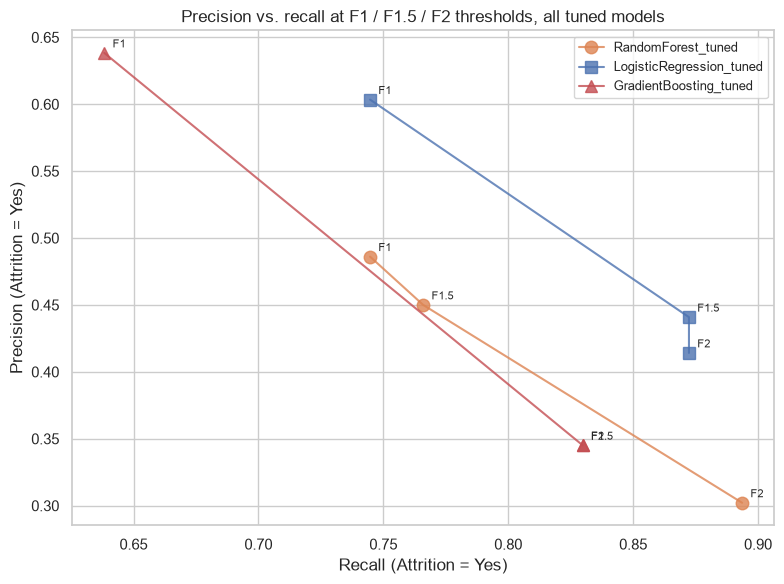

In [29]:
fbeta_only = fbeta_results_df[fbeta_results_df["Criterion"].isin(["F1", "F1.5", "F2"])]

fig, ax = plt.subplots(figsize=(8, 6))
model_markers = {"RandomForest_tuned": "o", "LogisticRegression_tuned": "s", "GradientBoosting_tuned": "^"}
model_colors = {"RandomForest_tuned": "#DD8452", "LogisticRegression_tuned": "#4C72B0", "GradientBoosting_tuned": "#C44E52"}

for model_name in tuned_models:
    sub = fbeta_only[fbeta_only["Model"] == model_name].sort_values("Criterion")
    ax.plot(sub["Test_Recall"], sub["Test_Precision"], color=model_colors[model_name],
            marker=model_markers[model_name], markersize=9, linestyle="-", alpha=0.8, label=model_name)
    for _, row in sub.iterrows():
        ax.annotate(row["Criterion"], (row["Test_Recall"], row["Test_Precision"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel("Recall (Attrition = Yes)")
ax.set_ylabel("Precision (Attrition = Yes)")
ax.set_title("Precision vs. recall at F1 / F1.5 / F2 thresholds, all tuned models")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Findings.**
- Under a consistent threshold-selection procedure, logistic regression attains the highest F1 among the three models (precision 0.60, recall 0.74, F1 0.667 at the F1 criterion), exceeding random forest (F1 0.588) and gradient boosting's own F1-optimal operating point (F1 0.638). At the F2 criterion, logistic regression also attains the highest precision (0.41) among the three models at comparable recall (0.87–0.89).
- This revises the characterization of gradient boosting reported in the preceding section. The reported precision-0.93/F1-0.68 result was obtained at the untouched default threshold (0.5), not at a selected operating point; gradient boosting's own F-beta-optimal threshold, selected using the same out-of-fold procedure applied to the other models, attains F1 = 0.638 on the test set — lower than the default-threshold result. This parallels the earlier observation that cross-validated performance does not guarantee test-set performance, applied here to threshold selection rather than hyperparameters, and is attributable in part to the limited training-set size (1,178 observations).
- The cost-ratio threshold (300–1800×) is not operationally usable: both bounds of the range produce a threshold near zero (0.0006–0.0033), yielding 100% recall and 15.9% precision — equal to the base attrition rate — for every model, corresponding to flagging the entire workforce. This is the Bayes-optimal decision under the stated cost structure in isolation, but does not account for a capacity constraint: retention conversations cannot realistically be conducted with the full workforce. A capacity-constrained targeting approach (Section 7) addresses this limitation.
- Constructing a per-employee cost ratio from `HourlyRate` or `MonthlyIncome` does not constitute data leakage, as these are legitimate input features available at prediction time and not derived from the target variable; the relevant limitation is that this dataset is documented as fictional (Section 1), so a cost estimate derived from it would be illustrative rather than an accurate financial figure.

- The cost-ratio formula assumes calibrated probabilities; the calibration check immediately above shows this assumption holds reasonably well for the tree ensembles but not for logistic regression under `class_weight="balanced"`, which is systematically overconfident. This does not change the degenerate-threshold conclusion below (driven by the extreme cost ratio itself), but it means the cost-ratio number would need a calibration step first if ever applied to logistic regression on real data.

### Capacity-Constrained Targeting (Top-K)

An alternative to a probability threshold ranks all test-set employees by predicted risk and selects the top K, where K reflects the number of interventions the organization can conduct. This approach avoids the degenerate behavior of the cost-ratio threshold above: no threshold value is required, and K can be set directly from available capacity (for example, a fixed number of retention conversations per period).

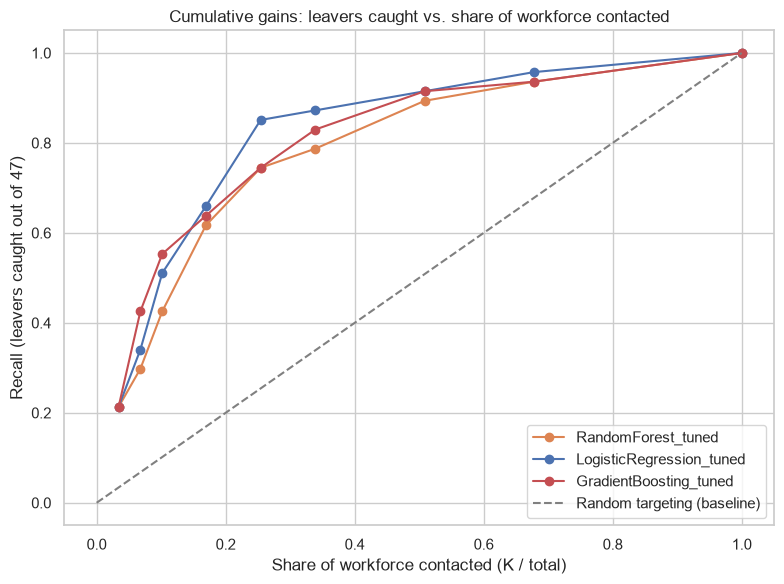

Model  GradientBoosting_tuned  LogisticRegression_tuned  RandomForest_tuned
K                                                                          
10                      0.213                     0.213               0.213
20                      0.426                     0.340               0.298
30                      0.553                     0.511               0.426
50                      0.638                     0.660               0.617
75                      0.745                     0.851               0.745
100                     0.830                     0.872               0.787
150                     0.915                     0.915               0.894
200                     0.936                     0.957               0.936
295                     1.000                     1.000               1.000

Precision at each K:
Model  GradientBoosting_tuned  LogisticRegression_tuned  RandomForest_tuned
K                                                                 

In [30]:
k_values = [10, 20, 30, 50, 75, 100, 150, 200, 295]
total_leavers = int(y_test.sum())

topk_results = []
for model_name, model in tuned_models.items():
    probs = model.predict_proba(X_test_processed)[:, 1]
    order = np.argsort(-probs)
    y_sorted = y_test.values[order]
    for k in k_values:
        caught = int(y_sorted[:k].sum())
        topk_results.append({
            "Model": model_name, "K": k, "Share_of_workforce": k / len(y_test),
            "Leavers_caught": caught, "Recall": caught / total_leavers,
            "Precision": caught / k,
        })

topk_df = pd.DataFrame(topk_results)

plt.figure(figsize=(8, 6))
colors = {"RandomForest_tuned": "#DD8452", "LogisticRegression_tuned": "#4C72B0", "GradientBoosting_tuned": "#C44E52"}
for model_name in tuned_models:
    sub = topk_df[topk_df["Model"] == model_name]
    plt.plot(sub["Share_of_workforce"], sub["Recall"], color=colors[model_name], marker="o", label=model_name)

# A random targeting policy would catch leavers proportional to K -- the diagonal baseline.
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random targeting (baseline)")

plt.xlabel("Share of workforce contacted (K / total)")
plt.ylabel(f"Recall (leavers caught out of {total_leavers})")
plt.title("Cumulative gains: leavers caught vs. share of workforce contacted")
plt.legend()
plt.tight_layout()
plt.show()

print(topk_df.pivot(index="K", columns="Model", values="Recall").round(3).to_string())
print()
print("Precision at each K:")
print(topk_df.pivot(index="K", columns="Model", values="Precision").round(3).to_string())

In [31]:
# GradientBoosting_tuned is the most precise ranker at small K (see table above) -- use it for a concrete example.
best_ranker = tuned_models["GradientBoosting_tuned"]
top20_probs = best_ranker.predict_proba(X_test_processed)[:, 1]

display_cols = ["JobRole", "MonthlyIncome", "OverTime", "YearsAtCompany", "BusinessTravel"]
top20 = X_test[display_cols].copy()
top20["predicted_risk"] = top20_probs
top20["actually_left"] = y_test.map({0: "No", 1: "Yes"}).values
top20 = top20.sort_values("predicted_risk", ascending=False).head(20).reset_index(drop=True)
top20.index = top20.index + 1
top20.index.name = "Rank"

print(f"Top 20 highest-risk employees in the test set (ranked by GradientBoosting_tuned):")
print(top20.round(3).to_string())
print()
print(f"Of these 20, {(top20['actually_left'] == 'Yes').sum()} actually left "
      f"({(top20['actually_left'] == 'Yes').mean():.0%} precision at K=20).")

Top 20 highest-risk employees in the test set (ranked by GradientBoosting_tuned):
                    JobRole  MonthlyIncome OverTime  YearsAtCompany     BusinessTravel  predicted_risk actually_left
Rank                                                                                                                
1      Sales Representative           2121      Yes               1      Travel_Rarely           0.954           Yes
2      Sales Representative           1675      Yes               0      Travel_Rarely           0.913           Yes
3           Sales Executive           5765       No               5  Travel_Frequently           0.912           Yes
4     Laboratory Technician           2973       No               1      Travel_Rarely           0.865           Yes
5     Laboratory Technician           3172      Yes               0  Travel_Frequently           0.862           Yes
6           Human Resources           2863       No               1  Travel_Frequently           0.

**Findings.**
- All three models outperform random targeting, with the largest relative advantage at small K, corresponding to the capacity-constrained regime most relevant in practice.
- At small K, gradient boosting (tuned) provides the most precise ranking, not logistic regression. At K = 20 (6.8% of the test set), gradient boosting identifies 20 of 47 actual departures (recall 42.6%) at 100% precision. At K = 30, precision remains 86.7%, exceeding logistic regression (80.0%) and random forest (66.7%) at the same K.
- This does not contradict the earlier finding that logistic regression performs best under F-beta thresholds; rather, it indicates that model ranking depends on the deployment mode. A probability threshold evaluates each case independently across the full range of risk; top-K targeting depends only on ranking accuracy at the extreme high end of the distribution. Gradient boosting's tuned configuration (shallow trees, low learning rate) produces a comparatively precise ranking at the top of the distribution despite a lower overall ROC-AUC (0.867) than logistic regression.
- Practical implication: for small-capacity retention programs, ranking with gradient boosting and selecting the top K is preferred. As capacity increases (K approaching 100–150, recall approaching 90%), the performance gap between models narrows and a threshold-based approach using logistic regression becomes comparably effective.

## Feature Importance

Feature importance was examined using three complementary measures: impurity-based `feature_importances_` from random forest and gradient boosting (capturing both linear and non-linear relationships, subject to bias toward high-cardinality and continuous features), standardized coefficients from logistic regression (directly interpretable in direction and magnitude, but limited to linear relationships), and SHAP values for the two tree models, which correct the impurity bias and add a direction of effect that impurity importance cannot provide.

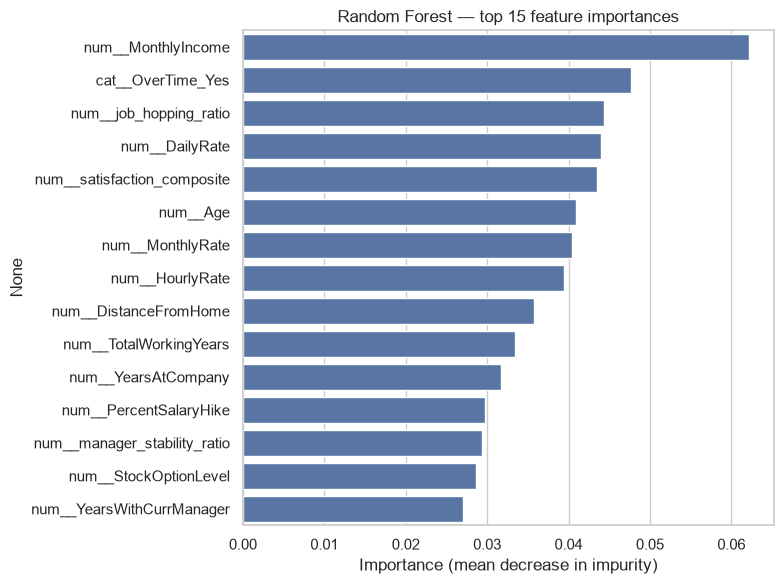

num__MonthlyIncome              0.062132
cat__OverTime_Yes               0.047730
num__job_hopping_ratio          0.044412
num__DailyRate                  0.043997
num__satisfaction_composite     0.043533
num__Age                        0.040972
num__MonthlyRate                0.040397
num__HourlyRate                 0.039411
num__DistanceFromHome           0.035725
num__TotalWorkingYears          0.033417
num__YearsAtCompany             0.031640
num__PercentSalaryHike          0.029698
num__manager_stability_ratio    0.029329
num__StockOptionLevel           0.028636
num__YearsWithCurrManager       0.027073
dtype: float64


In [32]:
feature_names = preprocessor.get_feature_names_out()

rf_importances = pd.Series(
    tuned_models["RandomForest_tuned"].feature_importances_, index=feature_names
).sort_values(ascending=False)

top_n = 15
plt.figure(figsize=(8, 6))
sns.barplot(x=rf_importances.head(top_n).values, y=rf_importances.head(top_n).index, color="#4C72B0")
plt.title(f"Random Forest — top {top_n} feature importances")
plt.xlabel("Importance (mean decrease in impurity)")
plt.tight_layout()
plt.show()

print(rf_importances.head(top_n))

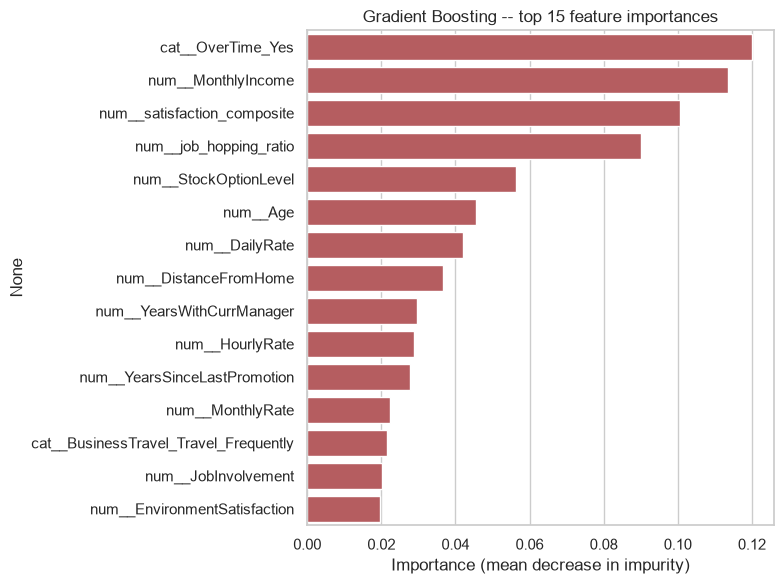

cat__OverTime_Yes                        0.119957
num__MonthlyIncome                       0.113481
num__satisfaction_composite              0.100577
num__job_hopping_ratio                   0.090059
num__StockOptionLevel                    0.056459
num__Age                                 0.045564
num__DailyRate                           0.041909
num__DistanceFromHome                    0.036500
num__YearsWithCurrManager                0.029682
num__HourlyRate                          0.028693
num__YearsSinceLastPromotion             0.027811
num__MonthlyRate                         0.022389
cat__BusinessTravel_Travel_Frequently    0.021477
num__JobInvolvement                      0.020160
num__EnvironmentSatisfaction             0.019614
dtype: float64


In [33]:
gb_importances = pd.Series(
    tuned_models["GradientBoosting_tuned"].feature_importances_, index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=gb_importances.head(top_n).values, y=gb_importances.head(top_n).index, color="#C44E52")
plt.title(f"Gradient Boosting -- top {top_n} feature importances")
plt.xlabel("Importance (mean decrease in impurity)")
plt.tight_layout()
plt.show()

print(gb_importances.head(top_n))

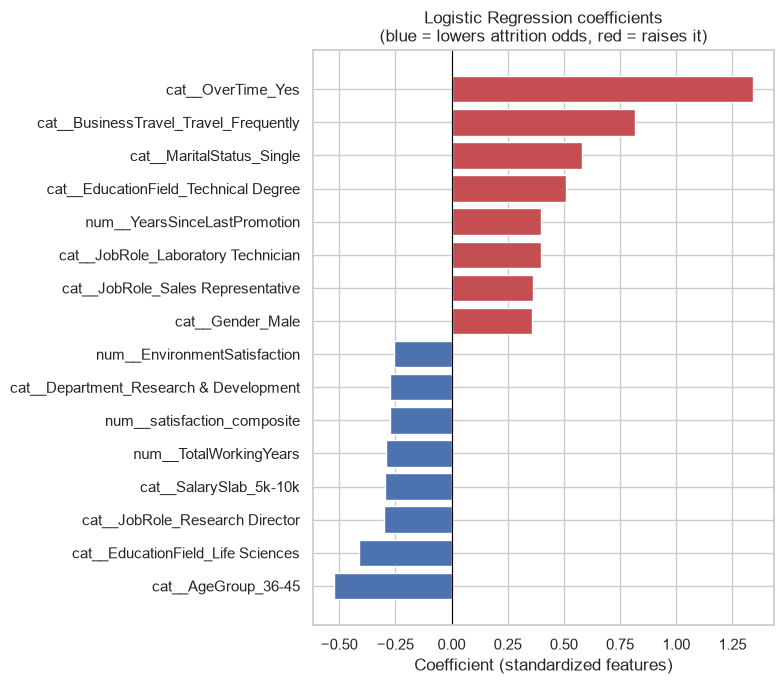

Lowers attrition odds most:
cat__AgeGroup_36-45                      -0.522444
cat__EducationField_Life Sciences        -0.411817
cat__JobRole_Research Director           -0.298945
cat__SalarySlab_5k-10k                   -0.298214
num__TotalWorkingYears                   -0.290834
num__satisfaction_composite              -0.272478
cat__Department_Research & Development   -0.271963
num__EnvironmentSatisfaction             -0.254096
dtype: float64

Raises attrition odds most:
cat__Gender_Male                         0.356378
cat__JobRole_Sales Representative        0.360521
cat__JobRole_Laboratory Technician       0.397068
num__YearsSinceLastPromotion             0.398614
cat__EducationField_Technical Degree     0.509747
cat__MaritalStatus_Single                0.578669
cat__BusinessTravel_Travel_Frequently    0.818499
cat__OverTime_Yes                        1.341983
dtype: float64


In [34]:
logreg_coefs = pd.Series(
    tuned_models["LogisticRegression_tuned"].coef_[0], index=feature_names
).sort_values()

top_bottom = pd.concat([logreg_coefs.head(8), logreg_coefs.tail(8)])
bar_colors = ["#4C72B0" if v < 0 else "#C44E52" for v in top_bottom.values]

plt.figure(figsize=(8, 7))
plt.barh(top_bottom.index, top_bottom.values, color=bar_colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression coefficients\n(blue = lowers attrition odds, red = raises it)")
plt.xlabel("Coefficient (standardized features)")
plt.tight_layout()
plt.show()

print("Lowers attrition odds most:")
print(logreg_coefs.head(8))
print("\nRaises attrition odds most:")
print(logreg_coefs.tail(8))

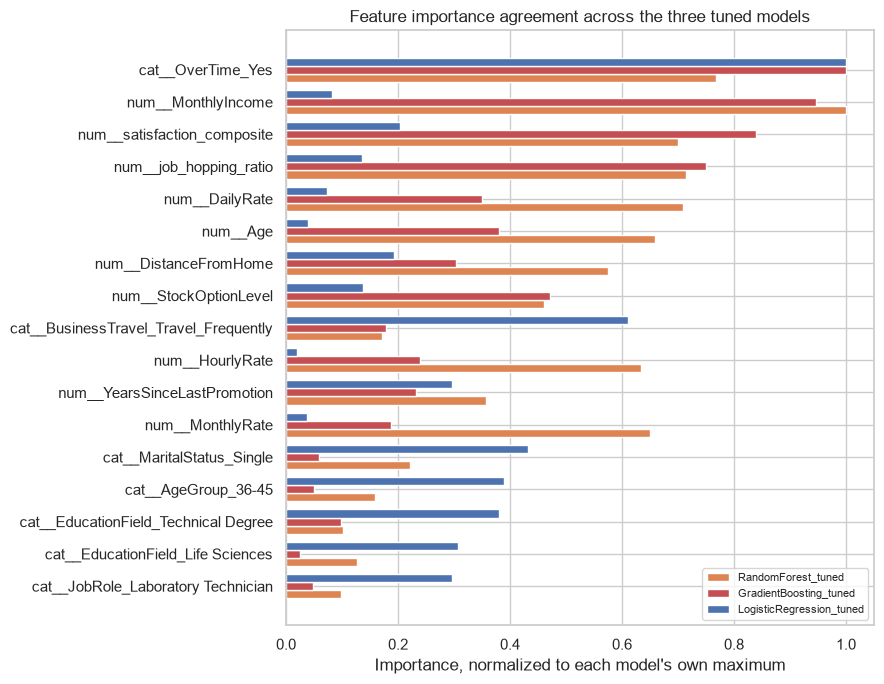

In [35]:
# Compare the three models directly on the union of their most important features.
# Tree-based importances and linear coefficients are not on the same scale, so each
# series is normalized to its own maximum for visual comparison of relative rank only.
rf_norm = rf_importances / rf_importances.max()
gb_norm = gb_importances / gb_importances.max()
logreg_abs = logreg_coefs.abs()
logreg_norm = logreg_abs / logreg_abs.max()

top_features = sorted(set(rf_norm.head(8).index) | set(gb_norm.head(8).index) | set(logreg_abs.sort_values(ascending=False).head(8).index))

comparison_df = pd.DataFrame({
    "RandomForest_tuned": rf_norm.reindex(top_features),
    "GradientBoosting_tuned": gb_norm.reindex(top_features),
    "LogisticRegression_tuned": logreg_norm.reindex(top_features),
}).fillna(0)
comparison_df = comparison_df.loc[comparison_df.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(9, 7))
y_pos = np.arange(len(comparison_df))
bar_height = 0.25
model_colors = {"RandomForest_tuned": "#DD8452", "GradientBoosting_tuned": "#C44E52", "LogisticRegression_tuned": "#4C72B0"}

for offset, model_name in zip([-bar_height, 0, bar_height], model_colors):
    ax.barh(y_pos + offset, comparison_df[model_name], height=bar_height,
            color=model_colors[model_name], label=model_name)

ax.set_yticks(y_pos)
ax.set_yticklabels(comparison_df.index)
ax.set_xlabel("Importance, normalized to each model's own maximum")
ax.set_title("Feature importance agreement across the three tuned models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Feature importance insights.**
- `MonthlyIncome` and `OverTime` are the two strongest individual predictors, consistent with the EDA and significance testing reported earlier.
- The engineered features contribute measurably to model performance. `job_hopping_ratio` ranks third in random forest importance, ahead of `Age`, `TotalWorkingYears`, and most raw columns, with a positive logistic regression coefficient (+0.18), indicating that job-switching frequency relative to career length carries more signal than raw company count. `satisfaction_composite` ranks fifth in random forest importance and is among the larger protective coefficients in logistic regression (−0.27), indicating that the composite index performs at least as well as the five ordinal scores from which it is derived. `manager_stability_ratio` ranks mid-table (random forest rank 13, coefficient −0.14). `is_new_hire` and `is_priority_employee` contribute more modestly (random forest ranks 39 and 27 respectively), substantially overlapping with the raw tenure and role features from which they were derived.
- Additional risk-elevating factors include frequent business travel, single marital status, employment as a sales representative or laboratory technician, and time since last promotion. `Gender_Male` also shows a moderate positive coefficient (+0.36) in the multivariate model; this is a partial effect conditional on other predictors and addresses a different statistical question from the earlier univariate finding that the effect of single marital status was comparable across genders — the two findings are not in conflict.
- The tenure-related features (`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, `TotalWorkingYears`, and the derived `job_hopping_ratio` and `manager_stability_ratio`) are correlated by construction; individual coefficients within this group should be interpreted collectively rather than in isolation.

### SHAP Values (Tree-Based Models)

The impurity-based `feature_importances_` used above are flagged in the section intro as biased toward high-cardinality and continuous features, and they only report magnitude, not the direction of a feature's effect. SHAP (`TreeExplainer`, exact for tree ensembles) addresses both: it decomposes each individual prediction into per-feature contributions, so it is not driven by how a feature happened to be used to split nodes during training, and the summary plot's color axis shows whether high or low feature values push risk up or down -- the same kind of directional read the logistic regression coefficients already give, now available for the two tree models. Computed on the full test set (n=295, small enough that no sampling is needed).

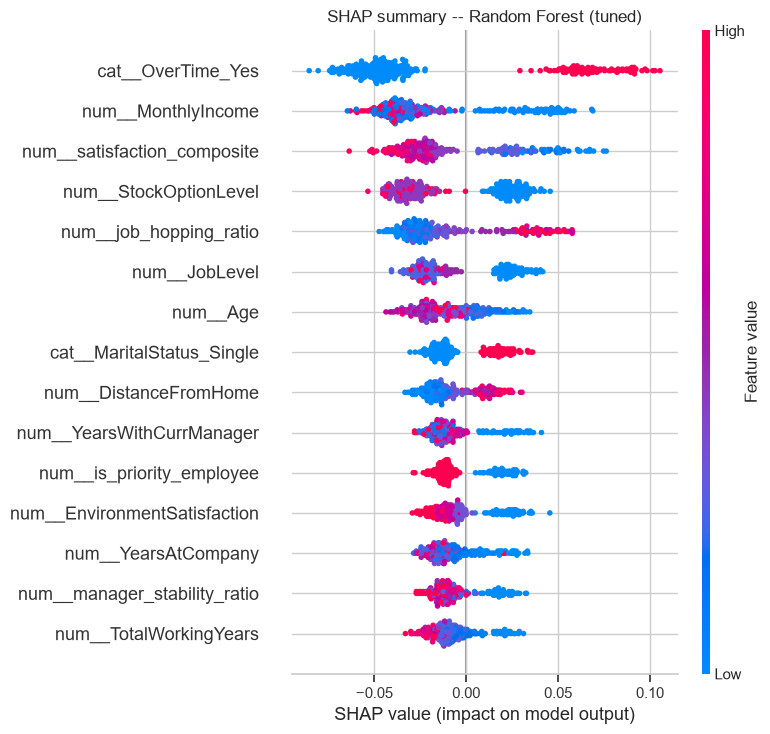

In [36]:
import shap

X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

explainer_rf = shap.TreeExplainer(tuned_models["RandomForest_tuned"])
shap_values_rf = explainer_rf(X_test_df)
if shap_values_rf.values.ndim == 3:
    # Binary classifiers: TreeExplainer can return per-class SHAP values --
    # keep the positive ("Yes", i.e. Attrition) class.
    shap_values_rf = shap_values_rf[..., 1]

explainer_gb = shap.TreeExplainer(tuned_models["GradientBoosting_tuned"])
shap_values_gb = explainer_gb(X_test_df)
if shap_values_gb.values.ndim == 3:
    shap_values_gb = shap_values_gb[..., 1]

shap.summary_plot(shap_values_rf, X_test_df, max_display=15, show=False)
plt.title("SHAP summary -- Random Forest (tuned)")
plt.tight_layout()
plt.show()

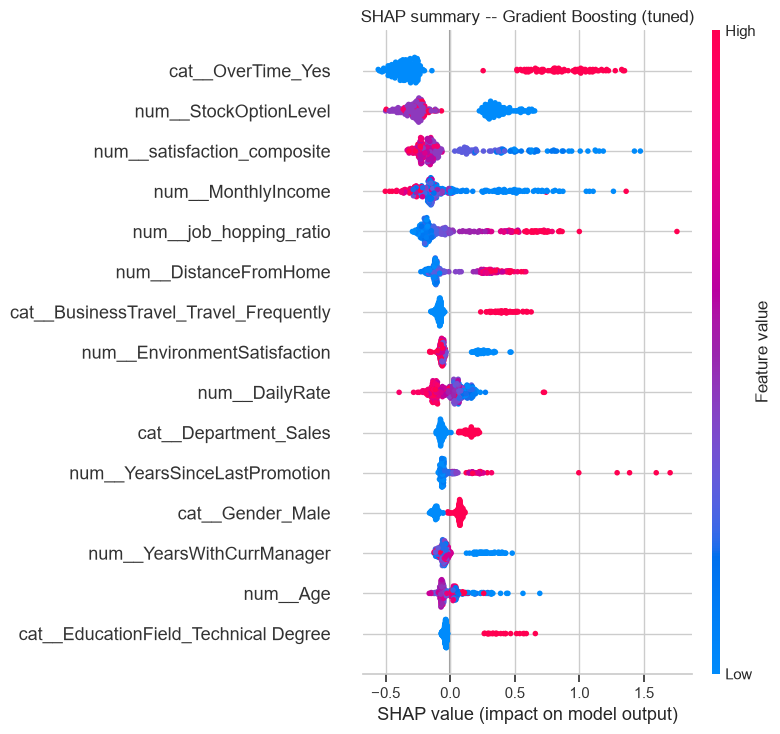

In [37]:
shap.summary_plot(shap_values_gb, X_test_df, max_display=15, show=False)
plt.title("SHAP summary -- Gradient Boosting (tuned)")
plt.tight_layout()
plt.show()

In [38]:
def shap_rank_table(shap_values, impurity_importances, top_n=15):
    mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_names)
    shap_rank = mean_abs_shap.rank(ascending=False)
    impurity_rank = impurity_importances.reindex(feature_names).rank(ascending=False)
    table = pd.DataFrame({
        "Mean |SHAP|": mean_abs_shap,
        "SHAP rank": shap_rank,
        "Impurity rank": impurity_rank,
        "Rank shift (impurity - SHAP)": impurity_rank - shap_rank,
    }).sort_values("Mean |SHAP|", ascending=False)
    return table.head(top_n)

pd.set_option("display.width", 160)
print("Random Forest -- SHAP rank vs impurity rank (top 15 by mean |SHAP|):")
print(shap_rank_table(shap_values_rf, rf_importances).round(3).to_string())
print()
print("Gradient Boosting -- SHAP rank vs impurity rank (top 15 by mean |SHAP|):")
print(shap_rank_table(shap_values_gb, gb_importances).round(3).to_string())

Random Forest -- SHAP rank vs impurity rank (top 15 by mean |SHAP|):
                              Mean |SHAP|  SHAP rank  Impurity rank  Rank shift (impurity - SHAP)
cat__OverTime_Yes                   0.055        1.0            2.0                           1.0
num__MonthlyIncome                  0.035        2.0            1.0                          -1.0
num__satisfaction_composite         0.029        3.0            5.0                           2.0
num__StockOptionLevel               0.028        4.0           14.0                          10.0
num__job_hopping_ratio              0.028        5.0            3.0                          -2.0
num__JobLevel                       0.023        6.0           17.0                          11.0
num__Age                            0.016        7.0            6.0                          -1.0
cat__MaritalStatus_Single           0.015        8.0           28.0                          20.0
num__DistanceFromHome               0.015        

**SHAP findings.**
- The impurity-bias caveat from the section intro is confirmed quantitatively here, not just asserted: one-hot categorical and ordinal-int features are the ones most underrated by impurity importance relative to SHAP. `MaritalStatus_Single` jumps from impurity rank 28 to SHAP rank 8 in random forest (+20); `Department_Sales` and `Gender_Male` jump from ranks 27 and 30 to SHAP ranks 10 and 12 in gradient boosting (+17, +18); `StockOptionLevel` and `JobLevel` (ordinal-int, few unique values) shift +10 and +11 in random forest. Impurity importance systematically favors features with many unique split points (continuous numerics), exactly the bias flagged at the top of this section.
- `StockOptionLevel` is the clearest new finding: it ranks 4th (random forest) and 2nd (gradient boosting) by mean |SHAP|, well ahead of its impurity rank (14th and 5th) -- higher stock option level is protective (lowers predicted risk), and neither the earlier impurity-importance nor logistic-regression-coefficient discussion called this out.
- Direction of effect (visible in the SHAP color axis, not available from impurity importance) is consistent with the rest of the notebook: `OverTime = Yes`, high `job_hopping_ratio`, single marital status, frequent business travel, and low tenure/income/satisfaction all push risk up; high `MonthlyIncome`, `StockOptionLevel`, `satisfaction_composite`, and `JobLevel` push it down.
- Two effects surface more clearly here than in the impurity or coefficient views: `Department_Sales` (gradient boosting) and `is_priority_employee` (random forest) -- both one-hot/binary features that impurity importance ranked in the high-20s but SHAP places in the top 10-15, in both cases pushing risk in the direction already established elsewhere in the notebook (Sales roles raise risk, `is_priority_employee` lowers it).

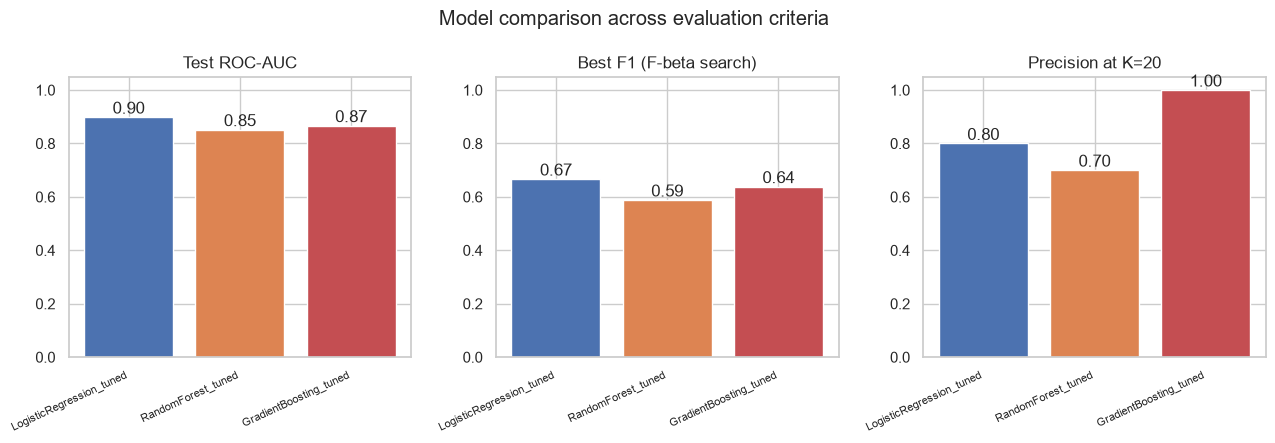

                          Test ROC-AUC  Best F1 (F-beta search)  Precision at K=20
Model                                                                             
LogisticRegression_tuned        0.8985                   0.6667                0.8
RandomForest_tuned              0.8516                   0.5882                0.7
GradientBoosting_tuned          0.8666                   0.6383                1.0


In [39]:
summary_comparison = pd.DataFrame({
    "Model": ["LogisticRegression_tuned", "RandomForest_tuned", "GradientBoosting_tuned"],
    "Test ROC-AUC": [
        roc_auc_score(y_test, tuned_models["LogisticRegression_tuned"].predict_proba(X_test_processed)[:, 1]),
        roc_auc_score(y_test, tuned_models["RandomForest_tuned"].predict_proba(X_test_processed)[:, 1]),
        roc_auc_score(y_test, tuned_models["GradientBoosting_tuned"].predict_proba(X_test_processed)[:, 1]),
    ],
    "Best F1 (F-beta search)": [
        fbeta_results_df.query("Model == 'LogisticRegression_tuned' and Criterion == 'F1'")["Test_F1"].iloc[0],
        fbeta_results_df.query("Model == 'RandomForest_tuned' and Criterion == 'F1'")["Test_F1"].iloc[0],
        fbeta_results_df.query("Model == 'GradientBoosting_tuned' and Criterion == 'F1'")["Test_F1"].iloc[0],
    ],
    "Precision at K=20": [
        topk_df.query("Model == 'LogisticRegression_tuned' and K == 20")["Precision"].iloc[0],
        topk_df.query("Model == 'RandomForest_tuned' and K == 20")["Precision"].iloc[0],
        topk_df.query("Model == 'GradientBoosting_tuned' and K == 20")["Precision"].iloc[0],
    ],
}).set_index("Model")

model_colors_bar = {"LogisticRegression_tuned": "#4C72B0", "RandomForest_tuned": "#DD8452", "GradientBoosting_tuned": "#C44E52"}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, metric in zip(axes, summary_comparison.columns):
    bars = ax.bar(summary_comparison.index, summary_comparison[metric],
                   color=[model_colors_bar[m] for m in summary_comparison.index])
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(summary_comparison.index)))
    ax.set_xticklabels(summary_comparison.index, rotation=25, ha="right", fontsize=8)
    ax.bar_label(bars, fmt="%.2f")

plt.suptitle("Model comparison across evaluation criteria")
plt.tight_layout()
plt.show()

print(summary_comparison.round(4).to_string())

**Summary.**
- The engineered features produced measurable improvements in the ensemble models: random forest's test ROC-AUC increased from 0.821 to 0.858, with `job_hopping_ratio` and `satisfaction_composite` ranking among the top five predictors by importance.
- Hyperparameter tuning did not uniformly improve test performance: it produced a marginal gain for logistic regression (0.897→0.899 AUC) but a reduction for random forest (0.858→0.852) and gradient boosting (0.869→0.867), illustrating that cross-validated performance gains do not guarantee test-set improvement.
- Model selection depends on the operational context. Under a consistent F-beta threshold-selection procedure, logistic regression is the strongest model. Under capacity-constrained top-K targeting, tuned gradient boosting provides the most precise ranking at small K. A naive cost-ratio threshold was evaluated and rejected as operationally infeasible.
- Investigation of role-specific and demographic questions raised during the analysis yielded several findings incorporated into the EDA and feature-engineering sections: frequent travel elevates risk across most roles; the effect of single marital status is comparable across genders; tenure at departure varies substantially by role; and time since promotion shows no univariate threshold effect. A data-entry inconsistency in `BusinessTravel` was identified and corrected.
- Subsequent sections address production pipeline assembly and a concluding assessment.

## Production Pipeline

Throughout this notebook, preprocessing and model fitting were performed as separate steps to facilitate inspection of intermediate output. Here, each tuned model is combined with its preprocessing transformer into a single `sklearn.Pipeline` object, which accepts raw employee records (in the format of `X_train`/`X_test`, prior to preprocessing) and returns predictions directly, eliminating the need for a separate transformation step at inference time.

In [40]:
from sklearn.base import clone
import joblib

final_pipelines = {}
for name, model in tuned_models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("classifier", clone(model)),
    ])
    pipeline.fit(X_train, y_train)
    final_pipelines[name] = pipeline

# Sanity check: the single-object Pipeline must reproduce the exact same test-set predictions
# as the manual preprocessor.transform() + model.predict_proba() calls used throughout this notebook.
print("Consistency check -- pipeline vs. manual preprocessing (should match exactly):")
for name, pipeline in final_pipelines.items():
    pipeline_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])
    manual_auc = roc_auc_score(y_test, tuned_models[name].predict_proba(X_test_processed)[:, 1])
    status = "OK" if abs(pipeline_auc - manual_auc) < 1e-9 else "MISMATCH"
    print(f"  {name:28s} pipeline={pipeline_auc:.4f}  manual={manual_auc:.4f}  [{status}]")

# Persist the two recommended pipelines (see Conclusion below for which to use when).
joblib.dump(final_pipelines["LogisticRegression_tuned"], "attrition_pipeline_logreg.joblib")
joblib.dump(final_pipelines["GradientBoosting_tuned"], "attrition_pipeline_gb.joblib")
print("\nSaved attrition_pipeline_logreg.joblib and attrition_pipeline_gb.joblib")
print("Reload with: joblib.load('attrition_pipeline_logreg.joblib').predict_proba(new_employee_df)")

Consistency check -- pipeline vs. manual preprocessing (should match exactly):


  RandomForest_tuned           pipeline=0.8516  manual=0.8516  [OK]
  LogisticRegression_tuned     pipeline=0.8985  manual=0.8985  [OK]
  GradientBoosting_tuned       pipeline=0.8666  manual=0.8666  [OK]

Saved attrition_pipeline_logreg.joblib and attrition_pipeline_gb.joblib
Reload with: joblib.load('attrition_pipeline_logreg.joblib').predict_proba(new_employee_df)


## Conclusion

**Problem statement.** This analysis predicts employee attrition risk to support prioritization of retention interventions, using demographic, compensation, and job-satisfaction data.

**Dataset limitation.** The dataset is IBM's documented fictional HR Analytics case study rather than real payroll data, established via the provenance assessment in Section 1 and corroborated by comparison against several genuinely non-informative synthetic datasets considered during dataset selection. It is suitable for demonstrating a complete modeling pipeline; application to real organizational data would require re-validation.

**Principal predictors.** Consistent across EDA, significance testing, and feature-importance analysis: overtime and below-median income are the strongest individual predictors; tenure exhibits a pronounced early-career effect (34.9% attrition in year one, declining to 8.1% after ten years, with substantial variation by role — median tenure at departure ranges from one year for sales representatives to 6–10 years for more senior roles); frequent business travel and single marital status are additional risk factors, with comparable effects across roles and genders respectively. Two engineered features, `job_hopping_ratio` and `satisfaction_composite`, rank among the top five predictors by importance.

**Model selection.** No single model is optimal across all use cases; the appropriate choice depends on the deployment mode, a conclusion reached through explicit comparison rather than assumed in advance.
- For threshold-based flagging, logistic regression (tuned) is recommended, as the most consistent model across F1, F1.5, and F2 criteria.
- For capacity-constrained outreach, gradient boosting (tuned) combined with top-K selection is recommended, providing the most precise ranking at small K (100% precision at K = 20 in this test set) despite a lower overall ROC-AUC than logistic regression.
- A cost-ratio-derived threshold was evaluated and rejected, as it produces a degenerate result (the entire workforce flagged) under the estimated cost structure; top-K selection is the corresponding practical alternative.

**Limitations.**
- The dataset is small (1,473 employees after cleaning), and test-set ROC-AUC swings by roughly 15-19 points across 20 resampled train/test splits for all three models -- confirmed directly via a repeated-split robustness check (Section 5), not merely inferred from a cross-validated-vs-test gap on a single split. Within that noise band, tuning's effect is not uniform: for random forest and logistic regression, the tuned-vs-baseline AUC difference is statistically indistinguishable from zero (paired t-test, p=0.31 and p=0.86 respectively, 20 splits); for gradient boosting, tuning produces a small but statistically significant improvement (+0.009 AUC, 95% CI excludes zero, p=0.0028). The single-split result reported for gradient boosting earlier in this notebook (tuned underperforming baseline) was therefore itself an artifact of an unfavorable draw, not a property of the tuning procedure.
- Several candidate features and modeling approaches were evaluated and rejected on quantitative grounds rather than assumed unhelpful: `promotion_stagnation_ratio`, `income_relative_to_joblevel`, a managerial/tenure-based outreach filter (which would exclude approximately 50% of actual departures), and a `Gender × MaritalStatus` interaction feature (rejected due to comparable effect sizes across genders).
- A leakage-safe, smoothed target-encoded `role × tenure` feature and a comparison against SMOTE were identified as potential extensions but not implemented, given the added complexity and leakage risk relative to the expected benefit at this sample size.
- `Gender_Male` and `MaritalStatus_Single` are both meaningful predictors in the tuned logistic regression model. The use of gender- and marital-status-correlated variables for employee risk scoring raises fairness considerations and, depending on jurisdiction, potential legal considerations that are not resolved in this analysis. Any deployment on real employee data should include an explicit decision regarding these features (for example, exclusion or a disparate-impact audit) independent of predictive performance.